# 🏛️ MPLADS-SATHI: AI-Powered Risk Intelligence Model
### *System for Automated Tracking, Hazard-detection & Inspection*

---

**SIH 2026 | Team CodeByPrakash**

This notebook implements the complete ML pipeline for the MPLADS-SATHI platform:

| Model | Technique | Purpose |
|:------|:----------|:--------|
| **Model 1** | XGBoost Binary Classifier | Detect anomalous vs. clean projects |
| **Model 2** | XGBoost Multiclass Classifier | Classify 6 anomaly archetypes |
| **Model 3** | Isolation Forest | Unsupervised outlier detection |
| **Fusion Engine** | Multi-criteria Scoring | Composite 0-100 risk score |

---

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1: IMPORTS & CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.ensemble import IsolationForest
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Fix pandas 3.0 string handling
pd.options.future.infer_string = False

# ─── Plot Configuration ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (14, 8),
    'figure.dpi': 100,
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.fontsize': 11,
})
sns.set_theme(style="whitegrid", palette="deep")

# Color palettes
RISK_COLORS = {'High Risk': '#e74c3c', 'Moderate Risk': '#f39c12', 'Clean / Exemplary': '#27ae60'}
ANOMALY_COLORS = {
    'clean': '#27ae60', 'delay_anomaly': '#e74c3c', 'cost_anomaly': '#e67e22',
    'duplicate_work': '#9b59b6', 'ghost_asset': '#2c3e50', 'vendor_anomaly': '#3498db',
    'payment_anomaly': '#e91e63'
}

print("All libraries loaded successfully!")
print(f"   NumPy: {np.__version__}")
print(f"   Pandas: {pd.__version__}")
print(f"   Scikit-learn: {__import__('sklearn').__version__}")
print(f"   XGBoost: {xgb.__version__}")

All libraries loaded successfully!
   NumPy: 2.4.6
   Pandas: 3.0.5
   Scikit-learn: 1.9.0
   XGBoost: 3.2.0


---
## 📂 Section 2: Data Loading & Initial Exploration

In [5]:
# ─── Load Datasets ────────────────────────────────────────────────────────
mp_df = pd.read_csv("dataset/mplads_mp_table.csv")
work_df = pd.read_csv("dataset/mplads_work_table.csv")
leaderboard_df = pd.read_csv("dataset/mplads_mp_risk_leaderboard.csv")

print("=" * 70)
print("  DATASET OVERVIEW")
print("=" * 70)
print(f"\n  MP Table:          {mp_df.shape[0]} rows × {mp_df.shape[1]} cols")
print(f"  Work Table:        {work_df.shape[0]} rows × {work_df.shape[1]} cols")
print(f"  Leaderboard:       {leaderboard_df.shape[0]} rows × {leaderboard_df.shape[1]} cols")
print(f"\n  States/UTs:        {work_df['state'].nunique()}")
print(f"  Work Categories:   {work_df['work_category'].nunique()}")
print(f"  Anomalous Works:   {work_df['is_anomalous'].sum()} ({work_df['is_anomalous'].mean()*100:.1f}%)")
print(f"  Clean Works:       {(work_df['is_anomalous']==0).sum()} ({(work_df['is_anomalous']==0).mean()*100:.1f}%)")
print("=" * 70)

  DATASET OVERVIEW

  MP Table:          542 rows × 15 cols
  Work Table:        15000 rows × 26 cols
  Leaderboard:       542 rows × 15 cols

  States/UTs:        36
  Work Categories:   8
  Anomalous Works:   9525 (63.5%)
  Clean Works:       5475 (36.5%)


In [6]:
# ─── Work Table Preview ───────────────────────────────────────────────────
print("\nWork Table — First 5 Rows:")
work_df.head()


Work Table — First 5 Rows:


,work_id,mp_id,mp_name,state,district,constituency,constituency_type,house,party,work_category,...,inspection_done,photo_available,photo_location_match,similar_work_count_500m,payment_count,is_anomalous,anomaly_type,cost_overrun_ratio,delay_days,cost_deviation_pct
0,W000375,1,Bishnu Pada Ray,Andaman And Nicobar Islands,Port Blair,ANDAMAN AND NICOBAR ISLANDS,General,Lok Sabha,TDP,Road,...,1,1,1,0,7,1,delay_anomaly,0.1270,329,13.91
1,W000878,1,Bishnu Pada Ray,Andaman And Nicobar Islands,Port Blair,ANDAMAN AND NICOBAR ISLANDS,General,Lok Sabha,TDP,Education,...,1,1,0,0,4,0,clean,-0.0156,0,-1.57
2,W000900,1,Bishnu Pada Ray,Andaman And Nicobar Islands,Port Blair,ANDAMAN AND NICOBAR ISLANDS,General,Lok Sabha,TDP,Road,...,0,1,1,0,4,0,clean,-0.0015,42,1.45
3,W001474,1,Bishnu Pada Ray,Andaman And Nicobar Islands,Port Blair,ANDAMAN AND NICOBAR ISLANDS,General,Lok Sabha,TDP,Community,...,0,1,1,0,4,0,clean,-0.1163,29,-7.24
4,W001525,1,Bishnu Pada Ray,Andaman And Nicobar Islands,Port Blair,ANDAMAN AND NICOBAR ISLANDS,General,Lok Sabha,TDP,Road,...,1,1,1,0,6,1,delay_anomaly,0.0583,78,8.02


In [7]:
# ─── Data Types & Missing Values ──────────────────────────────────────────
print("\nData Types & Null Counts:")
info_df = pd.DataFrame({
    'dtype': work_df.dtypes,
    'non_null': work_df.count(),
    'null_count': work_df.isnull().sum(),
    'null_pct': (work_df.isnull().sum() / len(work_df) * 100).round(2)
})
info_df


Data Types & Null Counts:


,dtype,non_null,null_count,null_pct
work_id,object,15000,0,0.0
mp_id,int64,15000,0,0.0
mp_name,object,15000,0,0.0
state,object,15000,0,0.0
district,object,15000,0,0.0
constituency,object,15000,0,0.0
constituency_type,object,15000,0,0.0
house,object,15000,0,0.0
party,object,15000,0,0.0
work_category,object,15000,0,0.0


In [8]:
# ─── MP Table Preview ─────────────────────────────────────────────────────
print("\nMP Table — First 5 Rows:")
mp_df.head()


MP Table — First 5 Rows:


,mp_id,mp_name,state,constituency,constituency_type,house,party,allocated_amount,released_amount,expenditure_amount,utilization_pct,total_works_recommended,total_works_completed,risk_tier,deviation_pct
0,1,Bishnu Pada Ray,Andaman And Nicobar Islands,ANDAMAN AND NICOBAR ISLANDS,General,Lok Sabha,TDP,1.470000e+08,1.241737e+08,6.797418e+07,46.24,77,52,Moderate Risk,0.00
1,2,Ambica G Lakshminarayana Valmiki,Andhra Pradesh,ANANTAPUR,General,Lok Sabha,INC,2.018991e+08,1.659631e+08,9.938119e+07,49.22,29,19,Moderate Risk,37.35
2,3,Appalanaidu Kalisetti,Andhra Pradesh,VIZIANAGARAM,General,Lok Sabha,BJP,1.470000e+08,1.284108e+08,9.706837e+07,66.03,32,29,Clean / Exemplary,0.00
3,4,B K Parthasarathi,Andhra Pradesh,HINDUPUR,General,Lok Sabha,INC,1.604919e+08,1.539177e+08,1.107941e+08,69.03,32,23,Clean / Exemplary,9.18
4,5,Balashowry Vallabbhaneni,Andhra Pradesh,MACHILIPATNAM,General,Lok Sabha,BJP,1.470000e+08,1.303552e+08,7.998727e+07,54.41,40,21,Moderate Risk,0.00


---
## Section 3: Data Cleaning & Feature Engineering

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
#  DATA CLEANING
# ═══════════════════════════════════════════════════════════════════════════

print("Starting data cleaning pipeline...\n")

# 1. Handle missing values
null_before = work_df.isnull().sum().sum()
work_df = work_df.fillna(0)
print(f"  Null values handled: {null_before} → {work_df.isnull().sum().sum()}")

# 2. Remove duplicates
dup_before = work_df.duplicated(subset=['work_id']).sum()
work_df = work_df.drop_duplicates(subset=['work_id'])
print(f"  Duplicate work_ids removed: {dup_before}")

# 3. Ensure proper dtypes
int_cols = ['expected_completion_days', 'actual_completion_days', 'inspection_done', 
            'photo_available', 'photo_location_match', 'similar_work_count_500m', 
            'payment_count', 'is_anomalous']
for col in int_cols:
    work_df[col] = work_df[col].astype(int)

float_cols = ['estimated_cost_inr', 'sanctioned_cost_inr', 'actual_expenditure_inr',
              'cost_overrun_ratio', 'delay_days', 'cost_deviation_pct']
for col in float_cols:
    work_df[col] = work_df[col].astype(float)
print(f"  Data types corrected")

# 4. Clip negative values in cost columns
for col in ['estimated_cost_inr', 'sanctioned_cost_inr', 'actual_expenditure_inr']:
    neg_count = (work_df[col] < 0).sum()
    if neg_count > 0:
        work_df[col] = work_df[col].clip(lower=0)
        print(f"  Clipped {neg_count} negative values in {col}")

# 5. Feature Engineering: Additional derived features
work_df['completion_ratio'] = (work_df['actual_completion_days'] / 
                                work_df['expected_completion_days'].clip(lower=1)).round(4)
work_df['cost_efficiency'] = (work_df['actual_expenditure_inr'] / 
                               work_df['sanctioned_cost_inr'].clip(lower=1)).round(4)
work_df['evidence_score'] = (work_df['inspection_done'] + work_df['photo_available'] + 
                              work_df['photo_location_match']) / 3
work_df['is_severely_delayed'] = (work_df['delay_days'] > 45).astype(int)

print(f"  Created derived features: completion_ratio, cost_efficiency, evidence_score, is_severely_delayed")
print(f"\nCleaning complete! Final shape: {work_df.shape}")

Starting data cleaning pipeline...

  Null values handled: 0 → 0
  Duplicate work_ids removed: 0
  Data types corrected
  Created derived features: completion_ratio, cost_efficiency, evidence_score, is_severely_delayed

Cleaning complete! Final shape: (15000, 30)


In [10]:
# ─── Statistical Summary ──────────────────────────────────────────────────
print("\nStatistical Summary of Key Features:")
summary_cols = ['estimated_cost_inr', 'sanctioned_cost_inr', 'actual_expenditure_inr',
                'expected_completion_days', 'actual_completion_days', 'delay_days',
                'cost_overrun_ratio', 'payment_count', 'similar_work_count_500m']
work_df[summary_cols].describe().round(2)


Statistical Summary of Key Features:


,estimated_cost_inr,sanctioned_cost_inr,actual_expenditure_inr,expected_completion_days,actual_completion_days,delay_days,cost_overrun_ratio,payment_count,similar_work_count_500m
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,2661824.61,3215397.59,3655177.54,89.25,152.93,66.04,0.09,4.95,0.70
std,1799859.69,2435836.36,3317225.14,37.21,109.97,102.21,0.23,3.33,1.13
min,101690.98,101134.87,88497.10,30.00,15.00,0.00,-0.20,1.00,0.00
25%,1292700.58,1474803.91,1531612.52,58.00,79.00,3.00,-0.06,3.00,0.00
50%,2278124.12,2616682.87,2735499.74,87.00,124.00,21.00,0.02,4.00,0.00
75%,3673459.72,4301398.62,4627431.15,114.00,185.00,81.00,0.16,7.00,1.00
max,9981075.51,22171203.98,39286036.31,179.00,706.00,587.00,1.00,19.00,5.00


---
## Section 4: Exploratory Data Analysis (EDA)

Rich visualizations to understand the MPLADS data patterns across all 36 states/UTs.

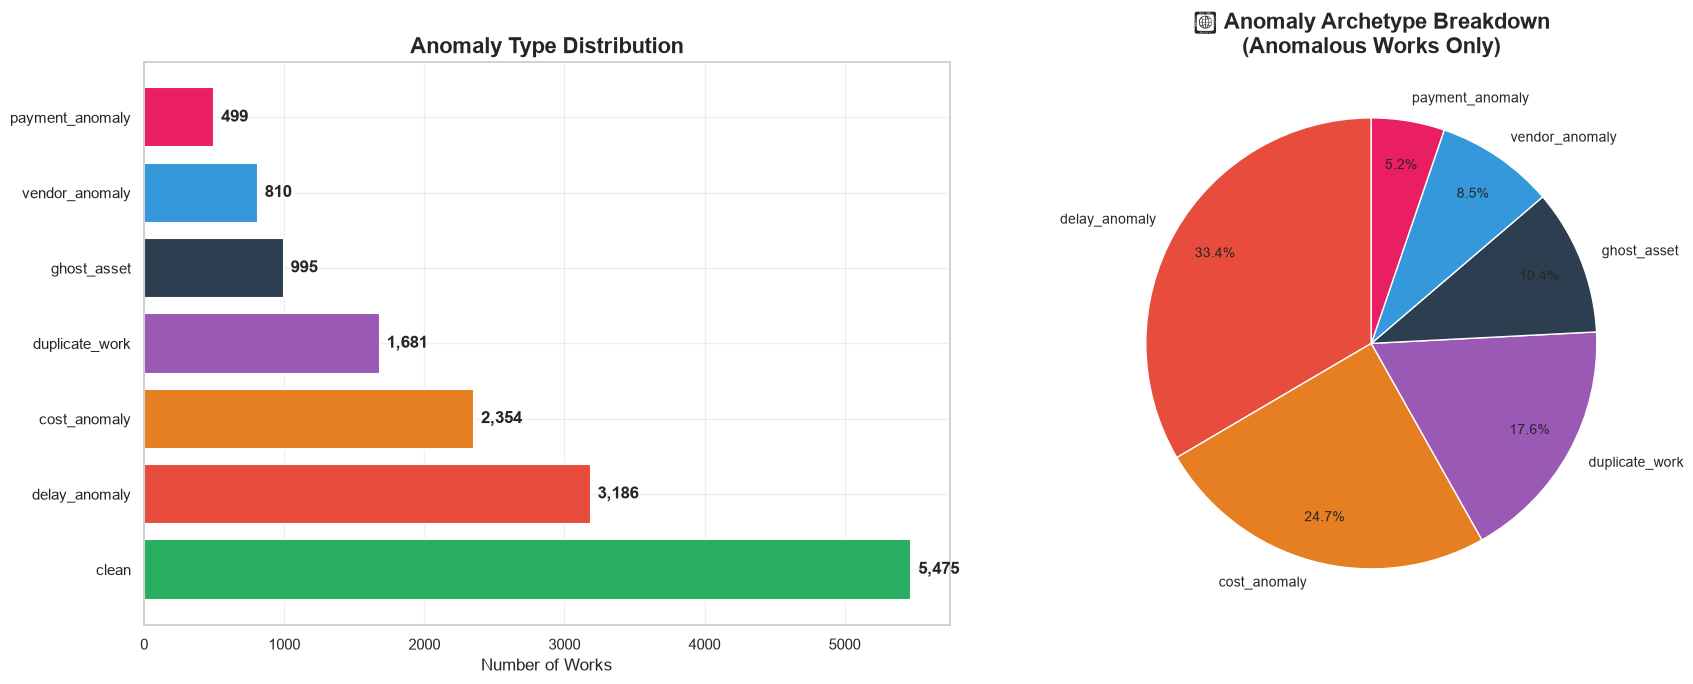

Saved: dataset/plot_anomaly_distribution.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.1: Anomaly Type Distribution
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart
anomaly_counts = work_df['anomaly_type'].value_counts()
colors = [ANOMALY_COLORS.get(x, '#95a5a6') for x in anomaly_counts.index]
bars = axes[0].barh(anomaly_counts.index, anomaly_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Number of Works')
axes[0].set_title('Anomaly Type Distribution', fontweight='bold', fontsize=16)
for bar, val in zip(bars, anomaly_counts.values):
    axes[0].text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontweight='bold')

# Pie chart
anomaly_only = work_df[work_df['is_anomalous'] == 1]['anomaly_type'].value_counts()
pie_colors = [ANOMALY_COLORS.get(x, '#95a5a6') for x in anomaly_only.index]
wedges, texts, autotexts = axes[1].pie(anomaly_only.values, labels=anomaly_only.index, 
                                        colors=pie_colors, autopct='%1.1f%%', startangle=90,
                                        textprops={'fontsize': 10}, pctdistance=0.8)
axes[1].set_title('🔍 Anomaly Archetype Breakdown\n(Anomalous Works Only)', fontweight='bold', fontsize=16)

plt.tight_layout()
plt.savefig('plots/plot_anomaly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_anomaly_distribution.png")

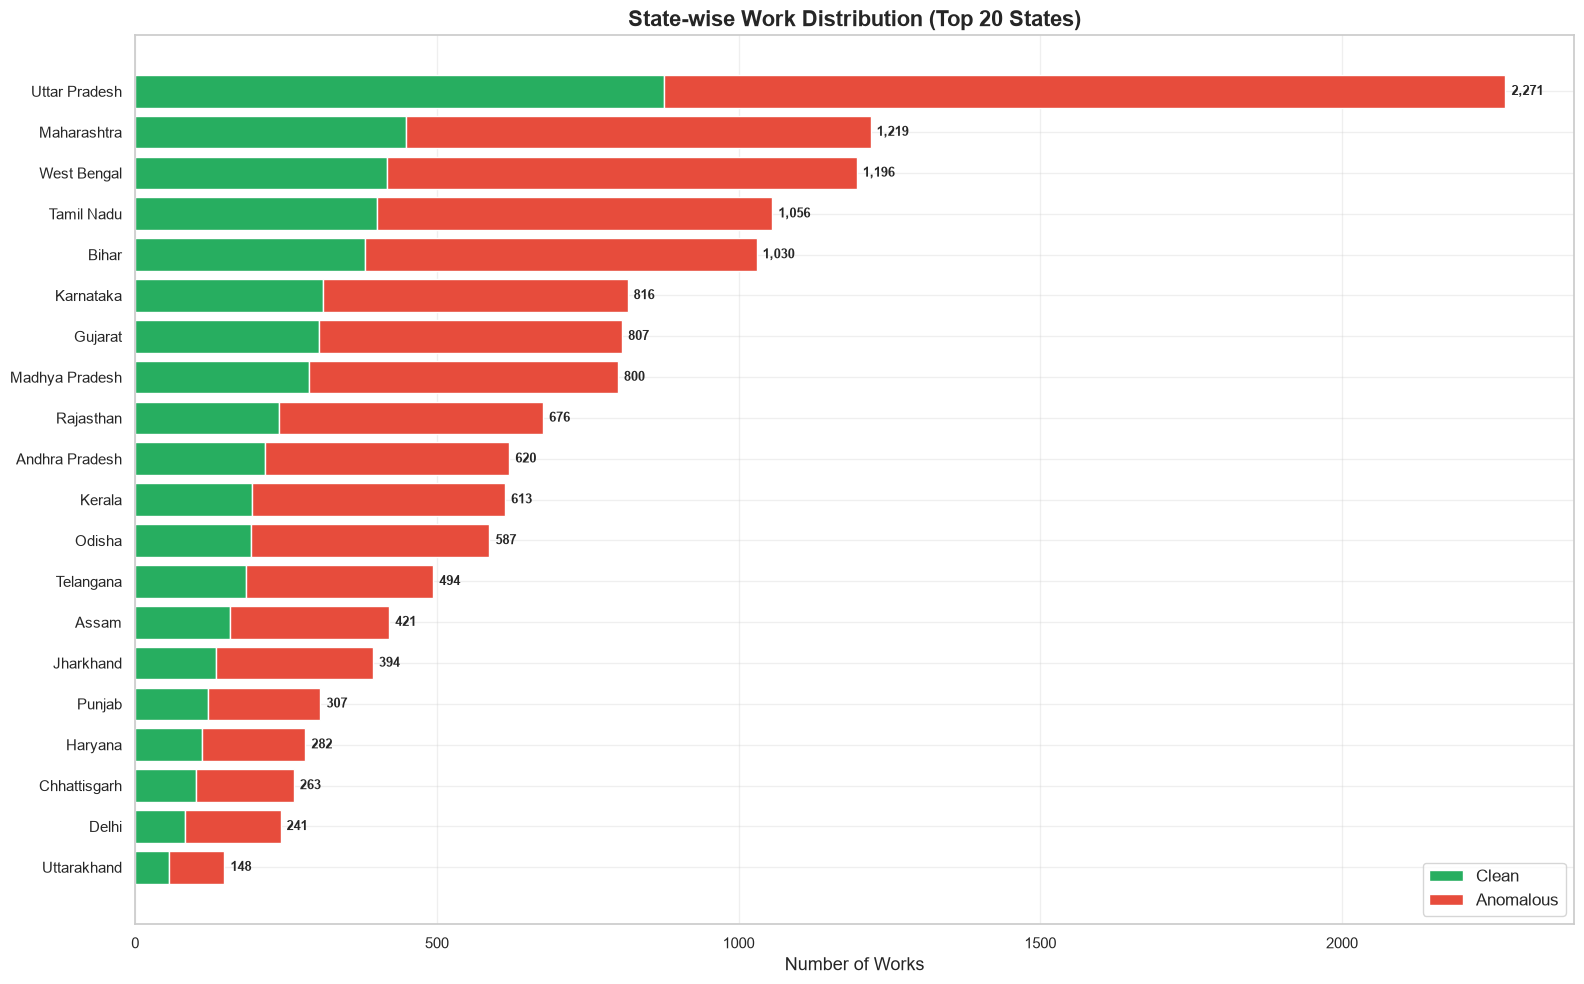

Saved: dataset/plot_state_distribution.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.2: State-wise Work Distribution (Top 20)
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 10))

state_counts = work_df.groupby('state').agg(
    total=('work_id', 'count'),
    anomalous=('is_anomalous', 'sum')
).sort_values('total', ascending=True).tail(20)

state_counts['clean'] = state_counts['total'] - state_counts['anomalous']

ax.barh(state_counts.index, state_counts['clean'], color='#27ae60', label='Clean', edgecolor='white')
ax.barh(state_counts.index, state_counts['anomalous'], left=state_counts['clean'], 
        color='#e74c3c', label='Anomalous', edgecolor='white')

ax.set_xlabel('Number of Works', fontsize=13)
ax.set_title('State-wise Work Distribution (Top 20 States)', fontweight='bold', fontsize=16)
ax.legend(fontsize=12, loc='lower right')

for i, (idx, row) in enumerate(state_counts.iterrows()):
    ax.text(row['total'] + 10, i, f"{row['total']:,}", va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('plots/plot_state_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_state_distribution.png")

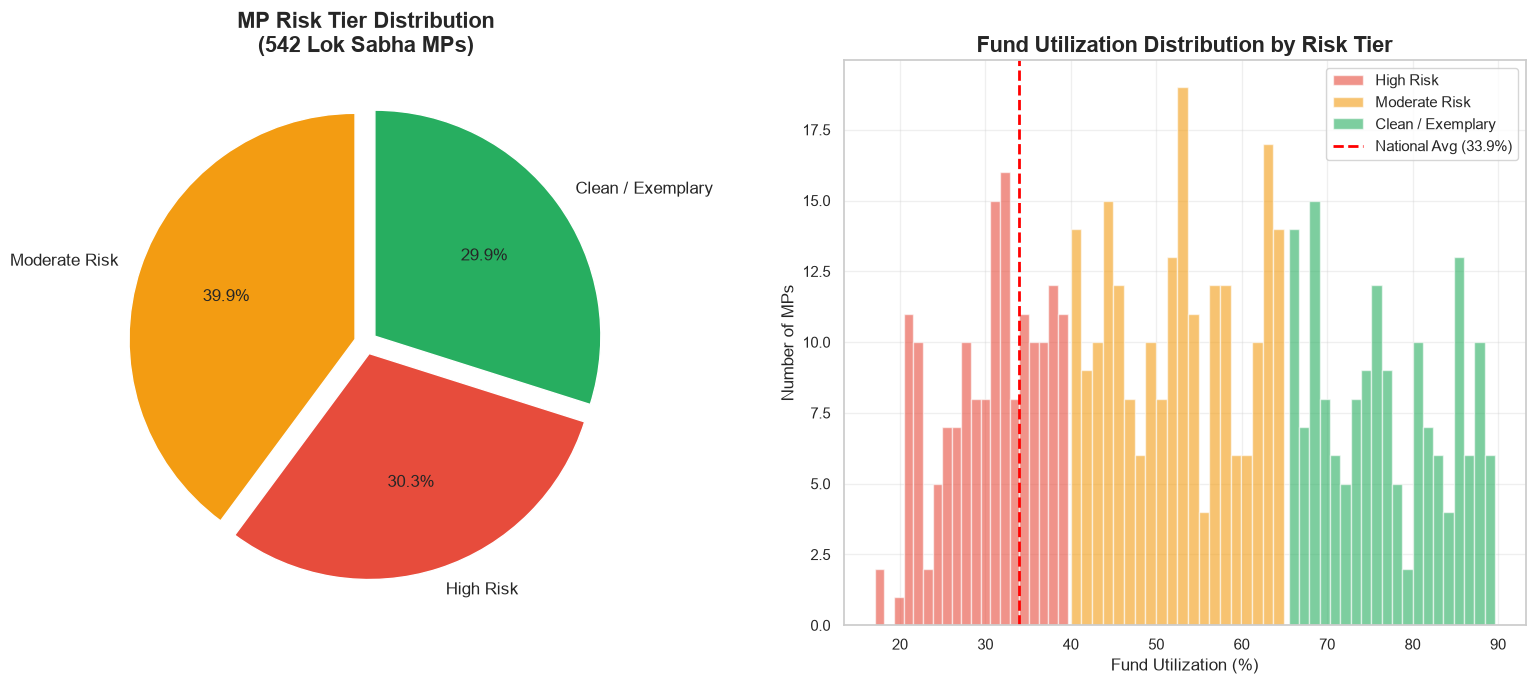

 Saved: dataset/plot_risk_tiers.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.3: MP Risk Tier Distribution
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart of risk tiers
risk_counts = mp_df['risk_tier'].value_counts()
tier_colors = [RISK_COLORS[t] for t in risk_counts.index]
wedges, texts, autotexts = axes[0].pie(risk_counts.values, labels=risk_counts.index,
                                        colors=tier_colors, autopct='%1.1f%%',
                                        startangle=90, textprops={'fontsize': 12},
                                        explode=[0.05]*len(risk_counts))
axes[0].set_title('MP Risk Tier Distribution\n(542 Lok Sabha MPs)', fontweight='bold', fontsize=16)

# Utilization histogram by risk tier
for tier in ['High Risk', 'Moderate Risk', 'Clean / Exemplary']:
    data = mp_df[mp_df['risk_tier'] == tier]['utilization_pct']
    axes[1].hist(data, bins=20, alpha=0.6, label=tier, color=RISK_COLORS[tier], edgecolor='white')

axes[1].axvline(x=33.9, color='red', linestyle='--', linewidth=2, label='National Avg (33.9%)')
axes[1].set_xlabel('Fund Utilization (%)')
axes[1].set_ylabel('Number of MPs')
axes[1].set_title('Fund Utilization Distribution by Risk Tier', fontweight='bold', fontsize=16)
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/plot_risk_tiers.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: plots/plot_risk_tiers.png")

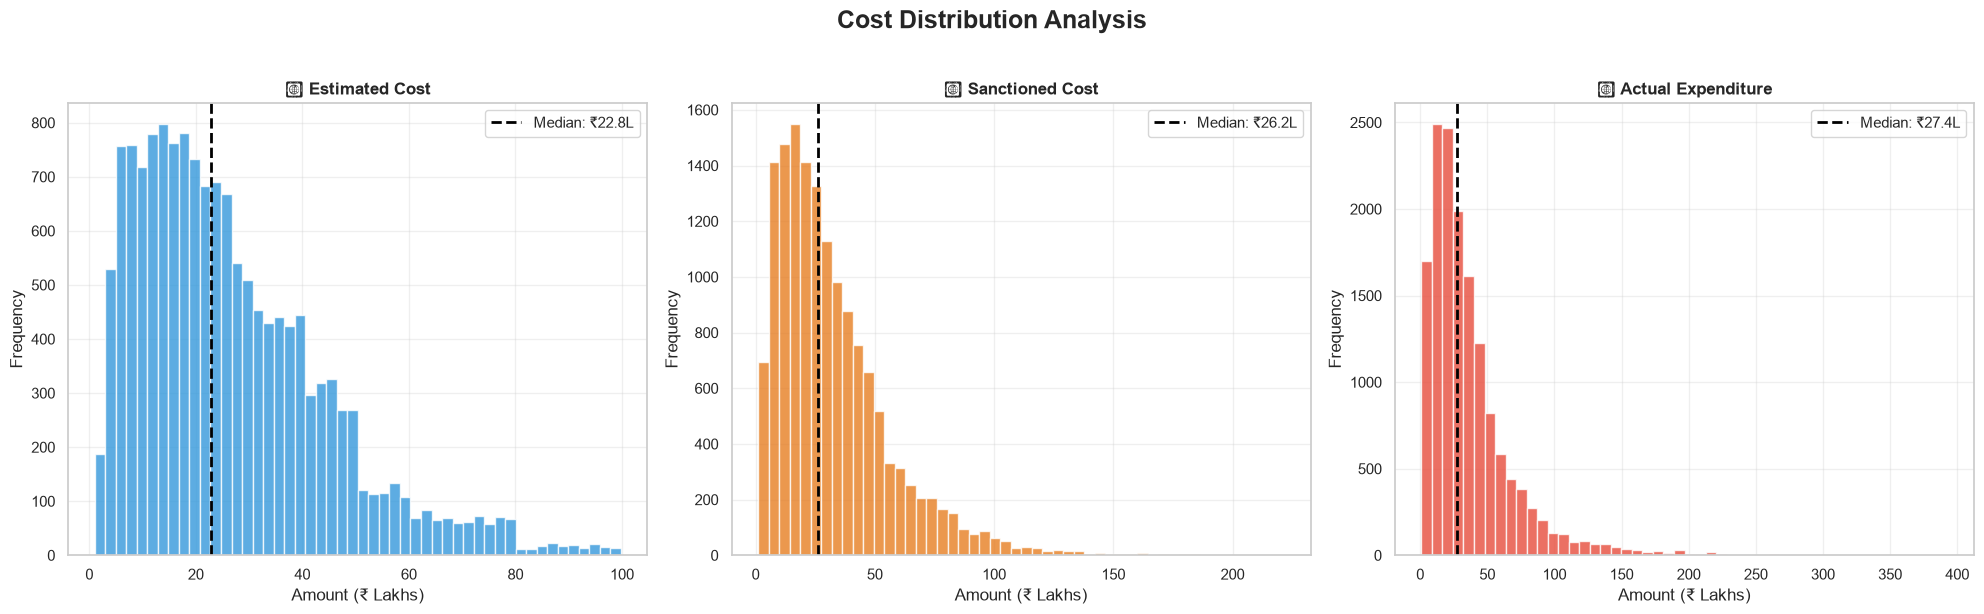

Saved: dataset/plot_cost_analysis.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.4: Cost Analysis — Estimated vs Sanctioned vs Actual
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Convert to lakhs for readability
for i, (col, title, color) in enumerate([
    ('estimated_cost_inr', 'Estimated Cost', '#3498db'),
    ('sanctioned_cost_inr', 'Sanctioned Cost', '#e67e22'),
    ('actual_expenditure_inr', 'Actual Expenditure', '#e74c3c')
]):
    data = work_df[col] / 100000  # Convert to lakhs
    axes[i].hist(data, bins=50, color=color, edgecolor='white', alpha=0.8)
    axes[i].axvline(data.median(), color='black', linestyle='--', linewidth=2, 
                     label=f'Median: ₹{data.median():.1f}L')
    axes[i].set_xlabel('Amount (₹ Lakhs)')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'💰 {title}', fontweight='bold')
    axes[i].legend()

plt.suptitle('Cost Distribution Analysis', fontweight='bold', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('plots/plot_cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_cost_analysis.png")

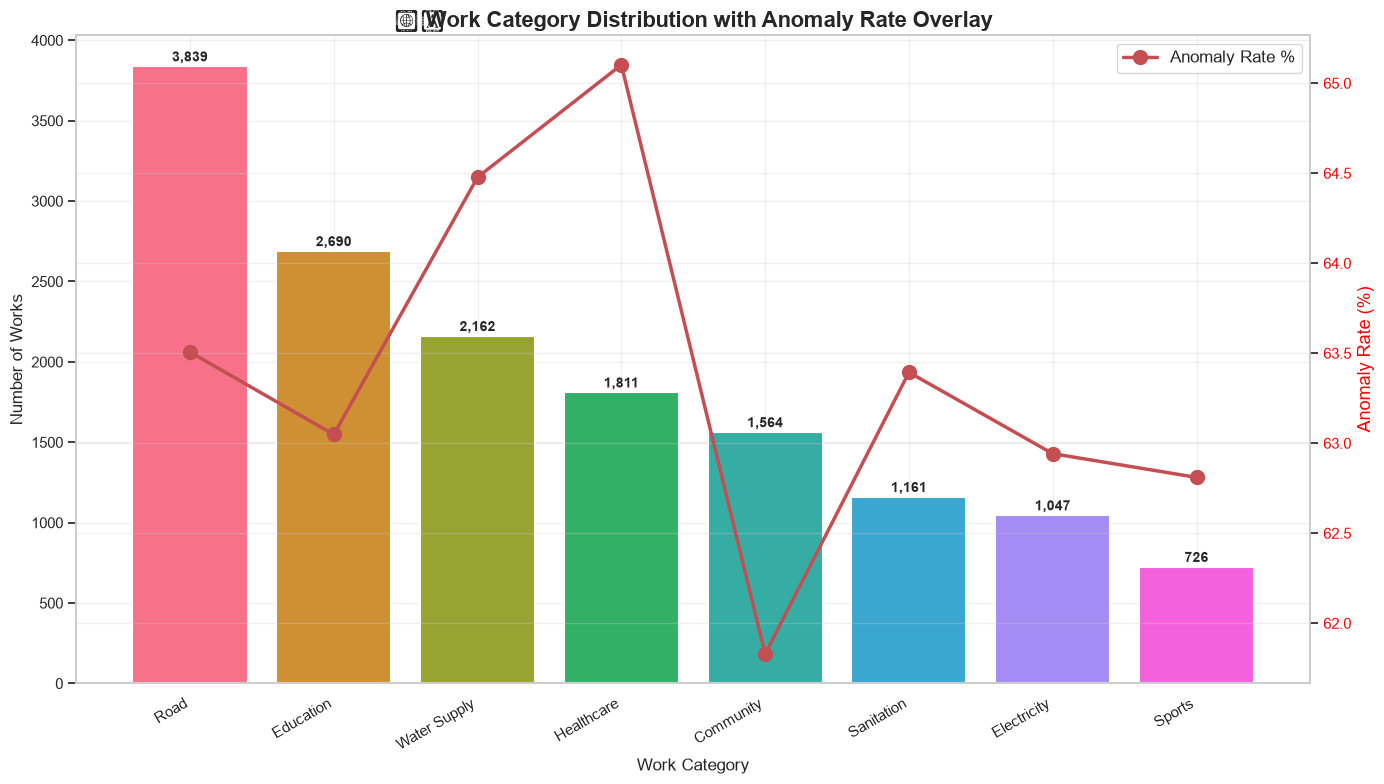

Saved: dataset/plot_work_categories.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.5: Work Category Distribution with Anomaly Rate
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 8))

cat_stats = work_df.groupby('work_category').agg(
    total=('work_id', 'count'),
    anomaly_rate=('is_anomalous', 'mean')
).sort_values('total', ascending=False)

x = range(len(cat_stats))
bars = ax.bar(x, cat_stats['total'], color=sns.color_palette("husl", len(cat_stats)), 
              edgecolor='white', linewidth=1.5)

# Add anomaly rate labels
ax2 = ax.twinx()
ax2.plot(x, cat_stats['anomaly_rate'] * 100, 'ro-', markersize=10, linewidth=2.5, label='Anomaly Rate %')
ax2.set_ylabel('Anomaly Rate (%)', color='red', fontsize=13)
ax2.tick_params(axis='y', labelcolor='red')

ax.set_xticks(x)
ax.set_xticklabels(cat_stats.index, rotation=30, ha='right')
ax.set_xlabel('Work Category')
ax.set_ylabel('Number of Works')
ax.set_title('🏗️ Work Category Distribution with Anomaly Rate Overlay', fontweight='bold', fontsize=16)

for bar, val in zip(bars, cat_stats['total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
            f'{val:,}', ha='center', fontweight='bold', fontsize=10)

ax2.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.savefig('plots/plot_work_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_work_categories.png")

---
## Section 5: Temperature & Heatmap Visualizations

State-wise risk heatmaps, feature correlation temperature plots, and anomaly-feature interaction heatmaps.

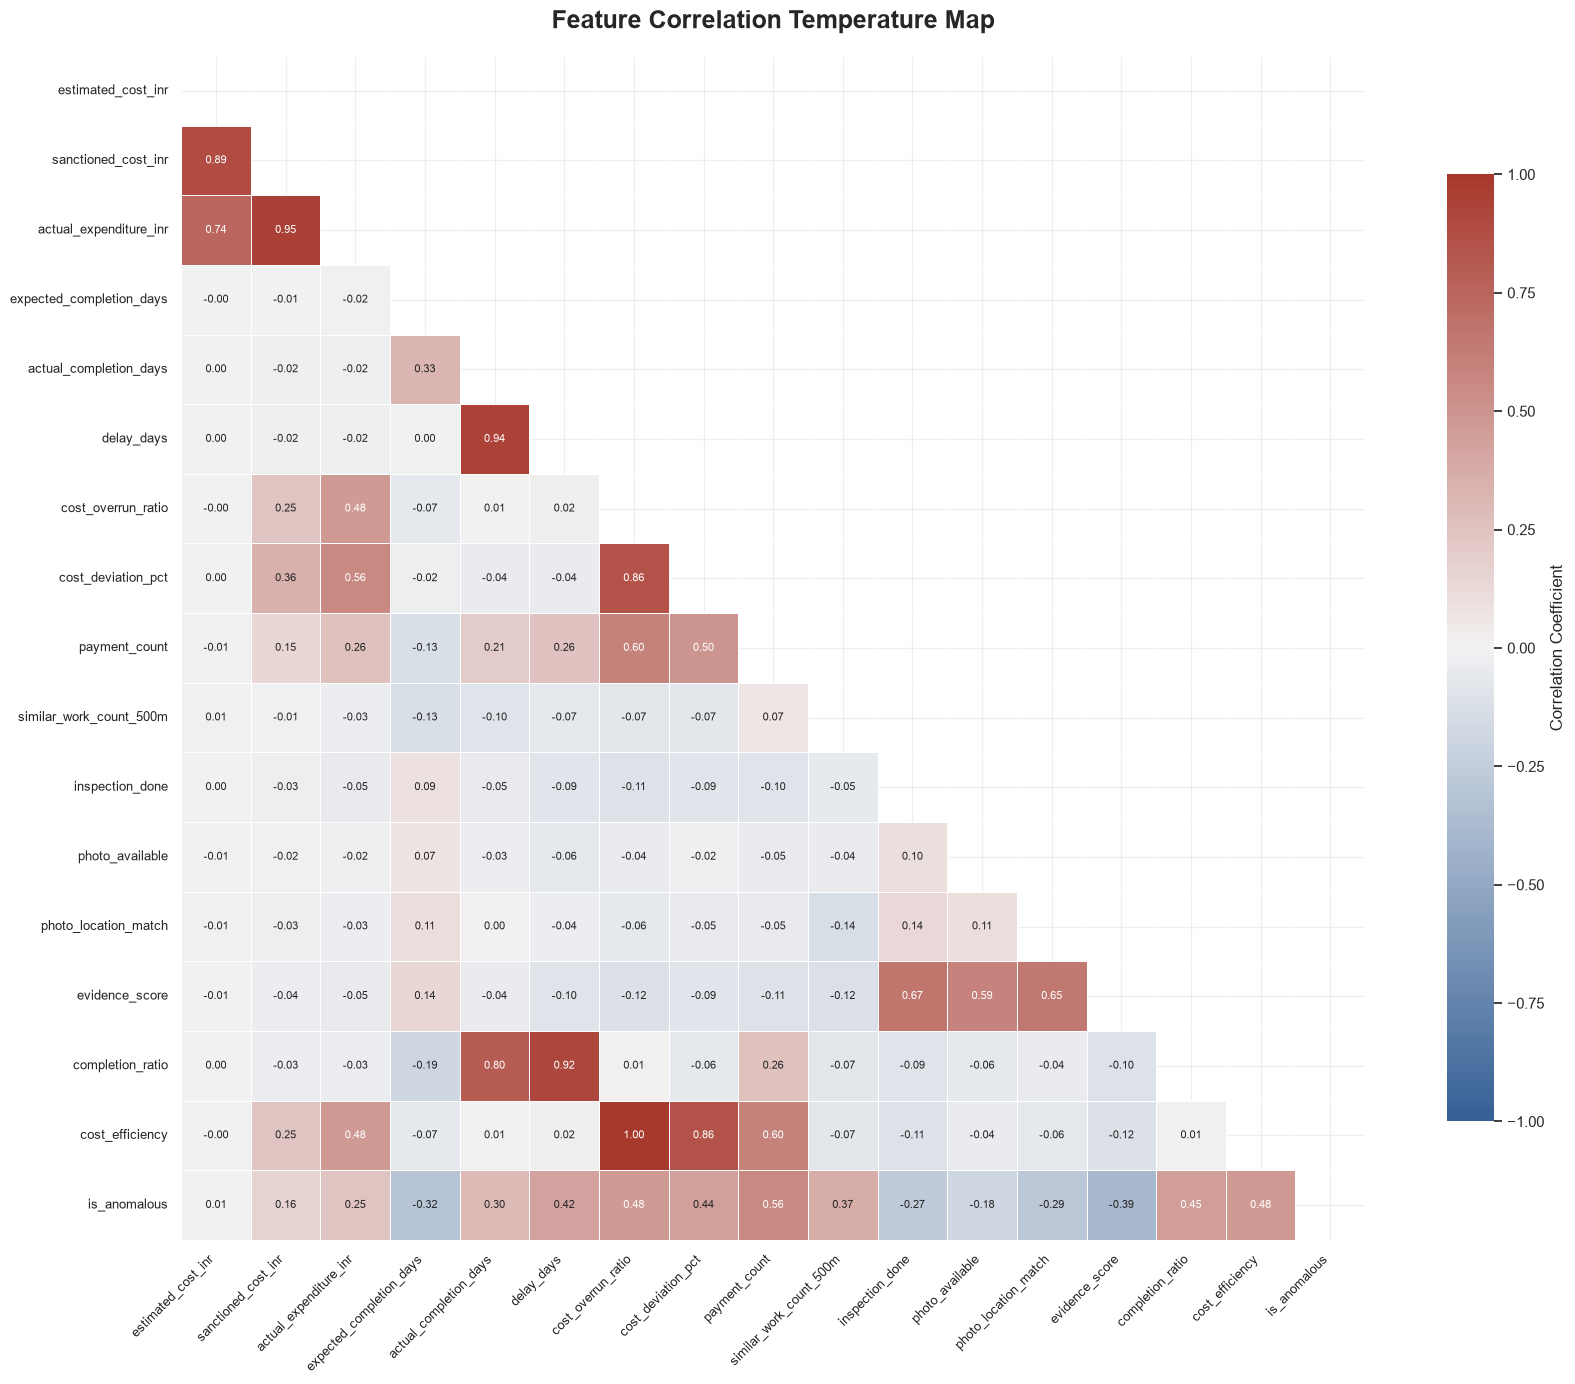

Saved: dataset/plot_correlation_heatmap.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.1: Feature Correlation Heatmap (Temperature Style)
# ═══════════════════════════════════════════════════════════════════════════

numeric_features = ['estimated_cost_inr', 'sanctioned_cost_inr', 'actual_expenditure_inr',
                    'expected_completion_days', 'actual_completion_days', 'delay_days',
                    'cost_overrun_ratio', 'cost_deviation_pct', 'payment_count',
                    'similar_work_count_500m', 'inspection_done', 'photo_available',
                    'photo_location_match', 'evidence_score', 'completion_ratio',
                    'cost_efficiency', 'is_anomalous']

corr_matrix = work_df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center="light", as_cmap=True)

hm = sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0, annot=True, fmt='.2f',
                  square=True, linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
                  annot_kws={"size": 8}, vmin=-1, vmax=1, ax=ax)

ax.set_title('Feature Correlation Temperature Map', fontweight='bold', fontsize=18, pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig('plots/plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_correlation_heatmap.png")

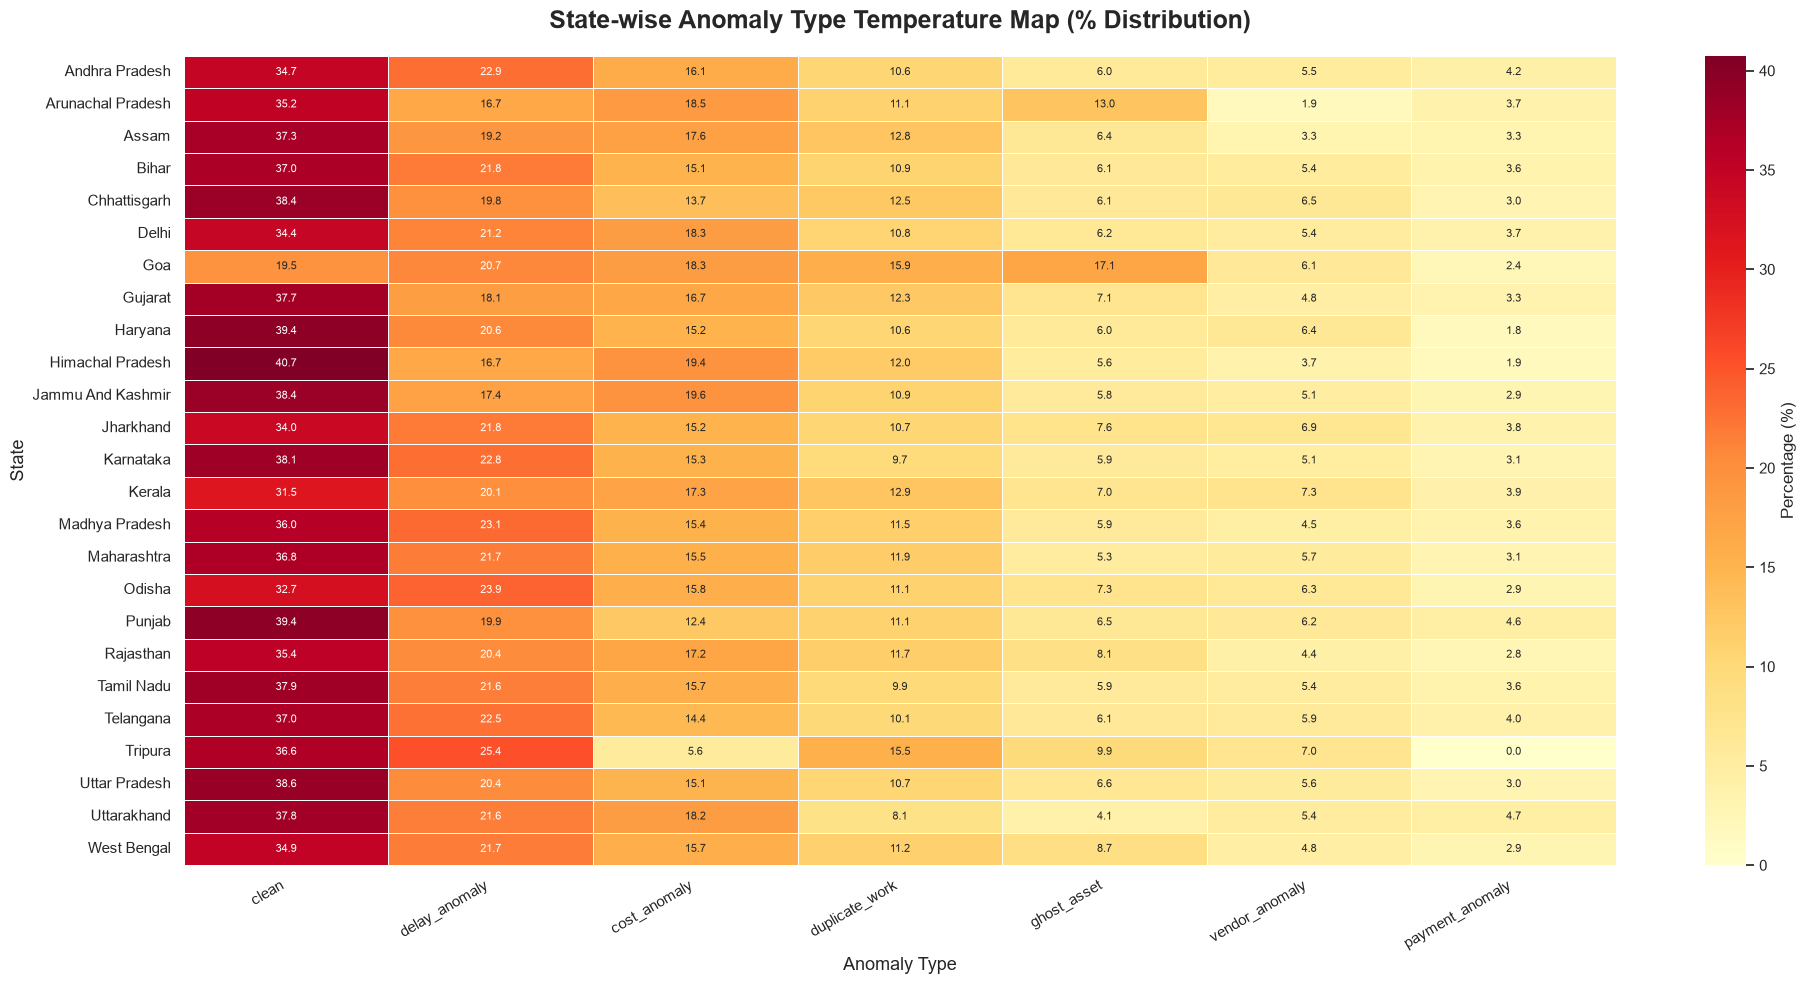

Saved: dataset/plot_state_risk_heatmap.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.2: State-wise Risk Temperature Map
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(20, 10))

# Create state-anomaly pivot
state_anomaly = work_df.groupby(['state', 'anomaly_type']).size().unstack(fill_value=0)
# Normalize each state row to percentages
state_anomaly_pct = state_anomaly.div(state_anomaly.sum(axis=1), axis=0) * 100

# Select top 25 states by work count
top_states = work_df['state'].value_counts().head(25).index
state_anomaly_pct = state_anomaly_pct.loc[state_anomaly_pct.index.isin(top_states)]

# Sort columns for better visualization
col_order = ['clean', 'delay_anomaly', 'cost_anomaly', 'duplicate_work', 
             'ghost_asset', 'vendor_anomaly', 'payment_anomaly']
col_order = [c for c in col_order if c in state_anomaly_pct.columns]
state_anomaly_pct = state_anomaly_pct[col_order]

sns.heatmap(state_anomaly_pct, cmap='YlOrRd', annot=True, fmt='.1f', 
            linewidths=0.5, cbar_kws={'label': 'Percentage (%)'}, ax=ax,
            annot_kws={"size": 8})

ax.set_title('State-wise Anomaly Type Temperature Map (% Distribution)', 
             fontweight='bold', fontsize=18, pad=20)
ax.set_xlabel('Anomaly Type', fontsize=13)
ax.set_ylabel('State', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('plots/plot_state_risk_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_state_risk_heatmap.png")

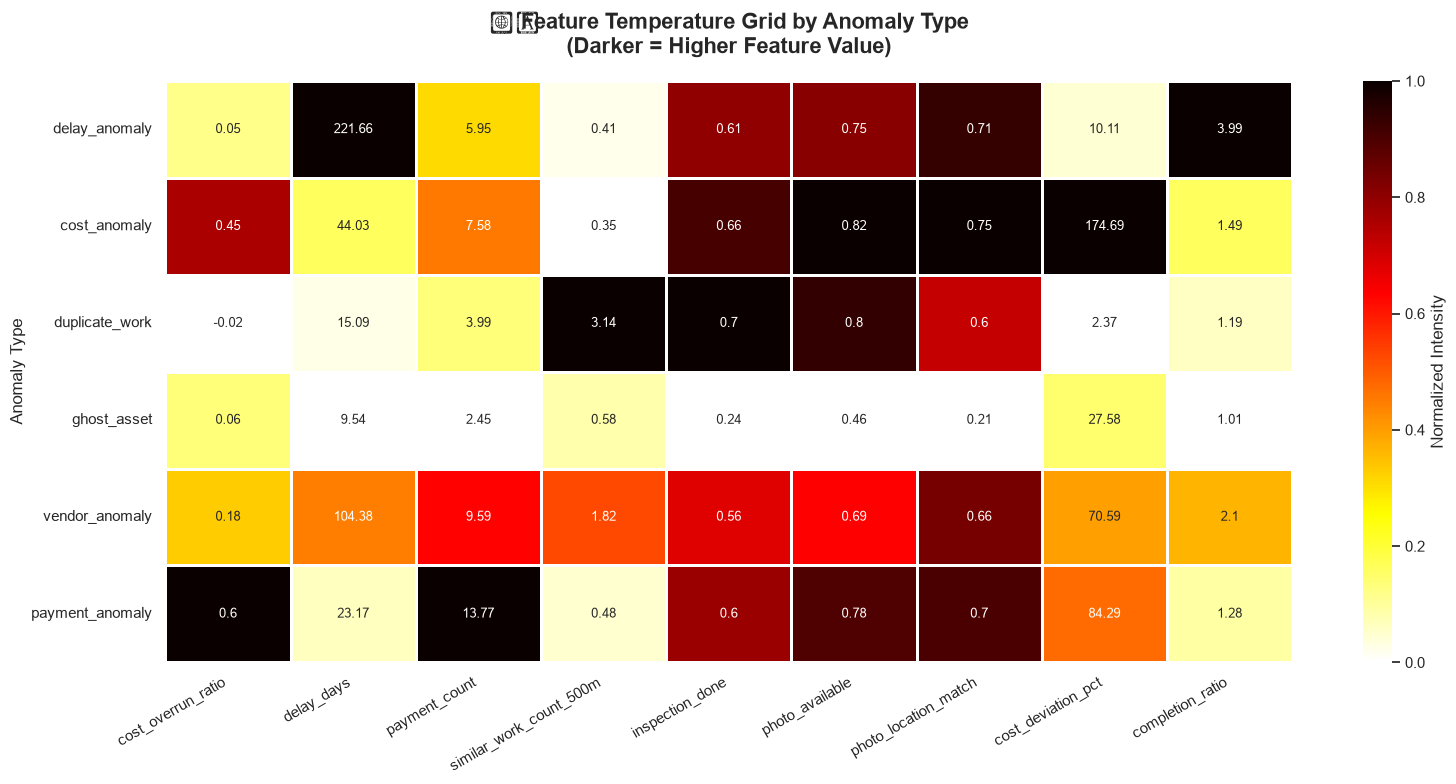

Saved: dataset/plot_feature_temperature.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.3: Feature Importance by Anomaly Type — Temperature Grid
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 8))

feature_cols = ['cost_overrun_ratio', 'delay_days', 'payment_count', 
                'similar_work_count_500m', 'inspection_done', 'photo_available',
                'photo_location_match', 'cost_deviation_pct', 'completion_ratio']

anomaly_types = ['delay_anomaly', 'cost_anomaly', 'duplicate_work', 
                 'ghost_asset', 'vendor_anomaly', 'payment_anomaly']

# Compute mean feature values for each anomaly type
means = []
for atype in anomaly_types:
    subset = work_df[work_df['anomaly_type'] == atype][feature_cols]
    means.append(subset.mean())

means_df = pd.DataFrame(means, index=anomaly_types, columns=feature_cols)

# Normalize to 0-1 range for temperature visualization
means_norm = (means_df - means_df.min()) / (means_df.max() - means_df.min() + 1e-10)

sns.heatmap(means_norm, cmap='hot_r', annot=means_df.round(2), fmt='', linewidths=1,
            cbar_kws={'label': 'Normalized Intensity'}, ax=ax, annot_kws={"size": 9})

ax.set_title('🌡️ Feature Temperature Grid by Anomaly Type\n(Darker = Higher Feature Value)', 
             fontweight='bold', fontsize=16, pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_ylabel('Anomaly Type')

plt.tight_layout()
plt.savefig('plots/plot_feature_temperature.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_feature_temperature.png")

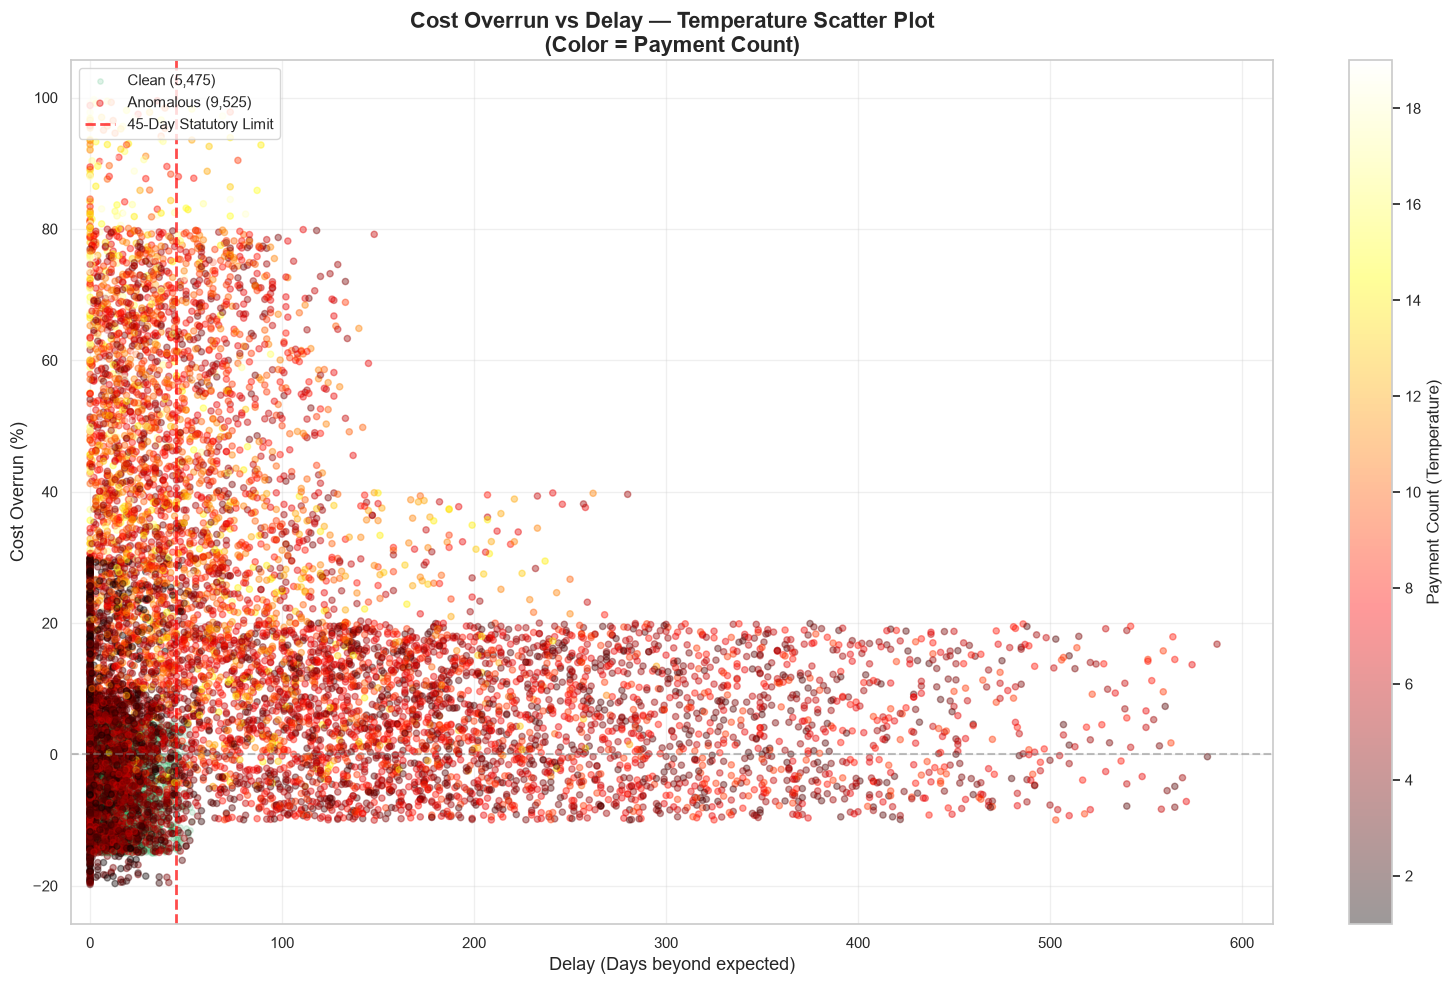

Saved: dataset/plot_cost_vs_delay_scatter.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.4: Cost vs Delay Scatter — Temperature Overlay
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 10))

# Clean vs anomalous scatter
clean = work_df[work_df['is_anomalous'] == 0]
anom = work_df[work_df['is_anomalous'] == 1]

ax.scatter(clean['delay_days'], clean['cost_overrun_ratio'] * 100, 
           c='#27ae60', alpha=0.15, s=15, label=f'Clean ({len(clean):,})')

scatter = ax.scatter(anom['delay_days'], anom['cost_overrun_ratio'] * 100,
                      c=anom['payment_count'], cmap='hot', alpha=0.4, s=20, 
                      label=f'Anomalous ({len(anom):,})')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Payment Count (Temperature)', fontsize=12)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=45, color='red', linestyle='--', linewidth=2, alpha=0.7, label='45-Day Statutory Limit')

ax.set_xlabel('Delay (Days beyond expected)', fontsize=13)
ax.set_ylabel('Cost Overrun (%)', fontsize=13)
ax.set_title('Cost Overrun vs Delay — Temperature Scatter Plot\n(Color = Payment Count)', 
             fontweight='bold', fontsize=16)
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(-10, ax.get_xlim()[1])

plt.tight_layout()
plt.savefig('plots/plot_cost_vs_delay_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_cost_vs_delay_scatter.png")

---
## Section 6: Model 1 — XGBoost Binary Risk Classifier

**Objective**: Classify each MPLADS work as `Clean (0)` or `Anomalous (1)`.

Uses XGBoost gradient boosting with stratified cross-validation.

In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL 1: XGBoost Binary Classifier — Feature Preparation
# ═══════════════════════════════════════════════════════════════════════════

# Select ML features
FEATURE_COLS = [
    'estimated_cost_inr', 'sanctioned_cost_inr', 'actual_expenditure_inr',
    'expected_completion_days', 'actual_completion_days',
    'inspection_done', 'photo_available', 'photo_location_match',
    'similar_work_count_500m', 'payment_count',
    'cost_overrun_ratio', 'delay_days', 'cost_deviation_pct',
    'completion_ratio', 'cost_efficiency', 'evidence_score'
]

X = work_df[FEATURE_COLS].copy()
y_binary = work_df['is_anomalous'].copy()

# Encode constituency_type as additional feature
le_const = LabelEncoder()
work_df['constituency_type_enc'] = le_const.fit_transform(work_df['constituency_type'].astype(str))
X['constituency_type_enc'] = work_df['constituency_type_enc']

# Train-test split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"Features:     {X_train.shape[1]}")
print(f"\nClass Distribution (Train):")
print(f"   Clean:     {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)")
print(f"   Anomalous: {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)")

Training set: 12,000 samples
Test set:     3,000 samples
Features:     17

Class Distribution (Train):
   Clean:     4,380 (36.5%)
   Anomalous: 7,620 (63.5%)


In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL 1: Training XGBoost Binary Classifier
# ═══════════════════════════════════════════════════════════════════════════

print("Training XGBoost Binary Classifier...\n")

xgb_binary = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_binary.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Predictions
y_pred_binary = xgb_binary.predict(X_test)
y_prob_binary = xgb_binary.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred_binary)
prec = precision_score(y_test, y_pred_binary)
rec = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)
roc = roc_auc_score(y_test, y_prob_binary)

print("=" * 60)
print("  MODEL 1: Binary Risk Classifier — Results")
print("=" * 60)
print(f"  Accuracy:     {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision:    {prec:.4f}")
print(f"  Recall:       {rec:.4f}")
print(f"  F1 Score:     {f1:.4f}")
print(f"  ROC-AUC:      {roc:.4f}")
print("=" * 60)

# Cross-validation
cv_scores = cross_val_score(xgb_binary, X, y_binary, cv=5, scoring='roc_auc')
print(f"\n  5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Training XGBoost Binary Classifier...

  MODEL 1: Binary Risk Classifier — Results
  Accuracy:     0.9970  (99.70%)
  Precision:    0.9989
  Recall:       0.9963
  F1 Score:     0.9976
  ROC-AUC:      0.9998

  5-Fold CV ROC-AUC: 0.9998 ± 0.0002


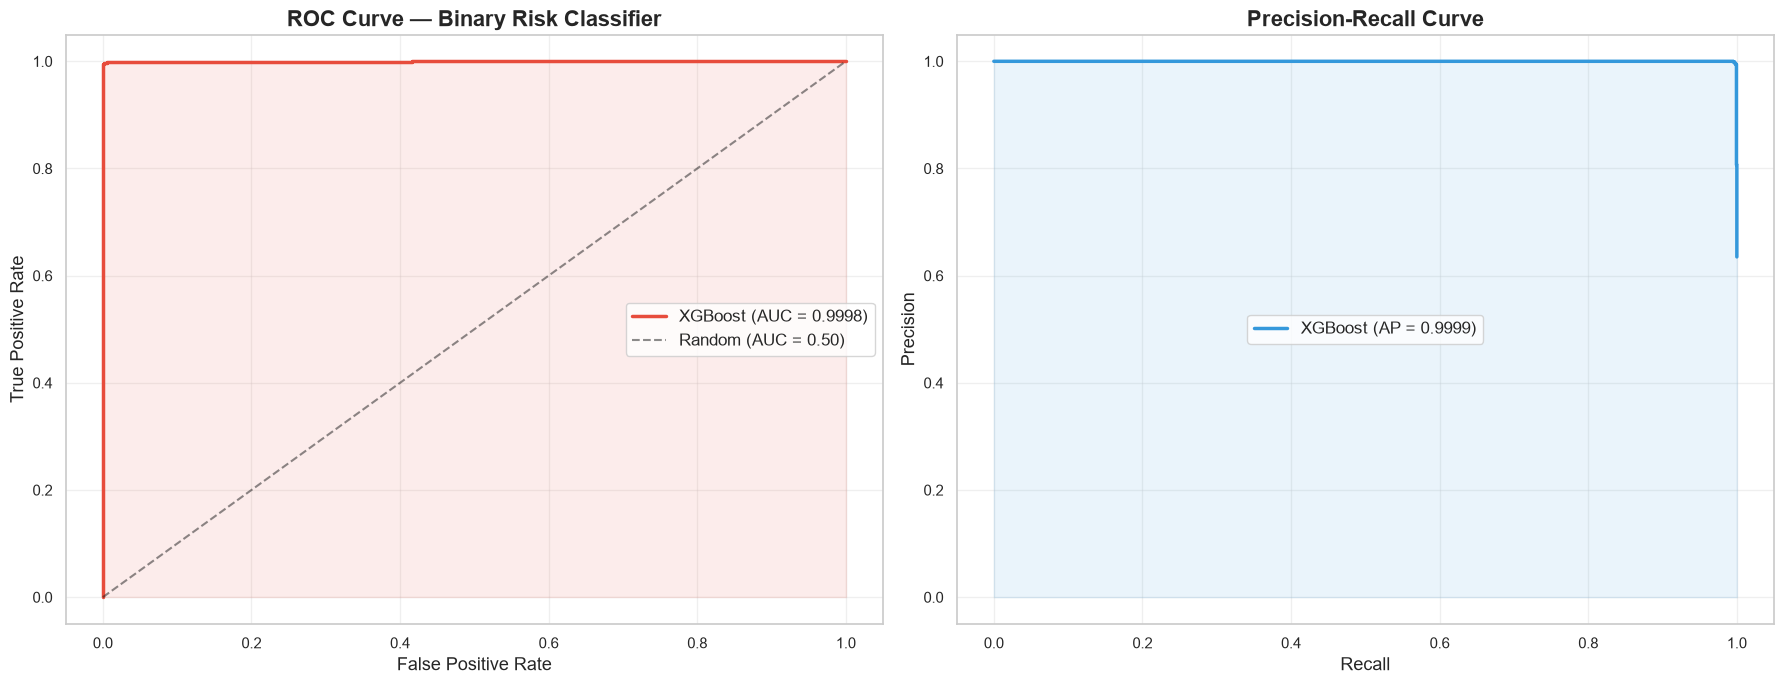

Saved: dataset/plot_binary_roc_pr.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL 1: ROC Curve & Precision-Recall Curve
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_binary)
axes[0].plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'XGBoost (AUC = {roc:.4f})')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=13)
axes[0].set_ylabel('True Positive Rate', fontsize=13)
axes[0].set_title('ROC Curve — Binary Risk Classifier', fontweight='bold', fontsize=16)
axes[0].legend(fontsize=12)

# Precision-Recall Curve
precision_curve, recall_curve_vals, _ = precision_recall_curve(y_test, y_prob_binary)
avg_prec = average_precision_score(y_test, y_prob_binary)
axes[1].plot(recall_curve_vals, precision_curve, color='#3498db', linewidth=2.5, 
             label=f'XGBoost (AP = {avg_prec:.4f})')
axes[1].fill_between(recall_curve_vals, precision_curve, alpha=0.1, color='#3498db')
axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title('Precision-Recall Curve', fontweight='bold', fontsize=16)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig('plots/plot_binary_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_binary_roc_pr.png")

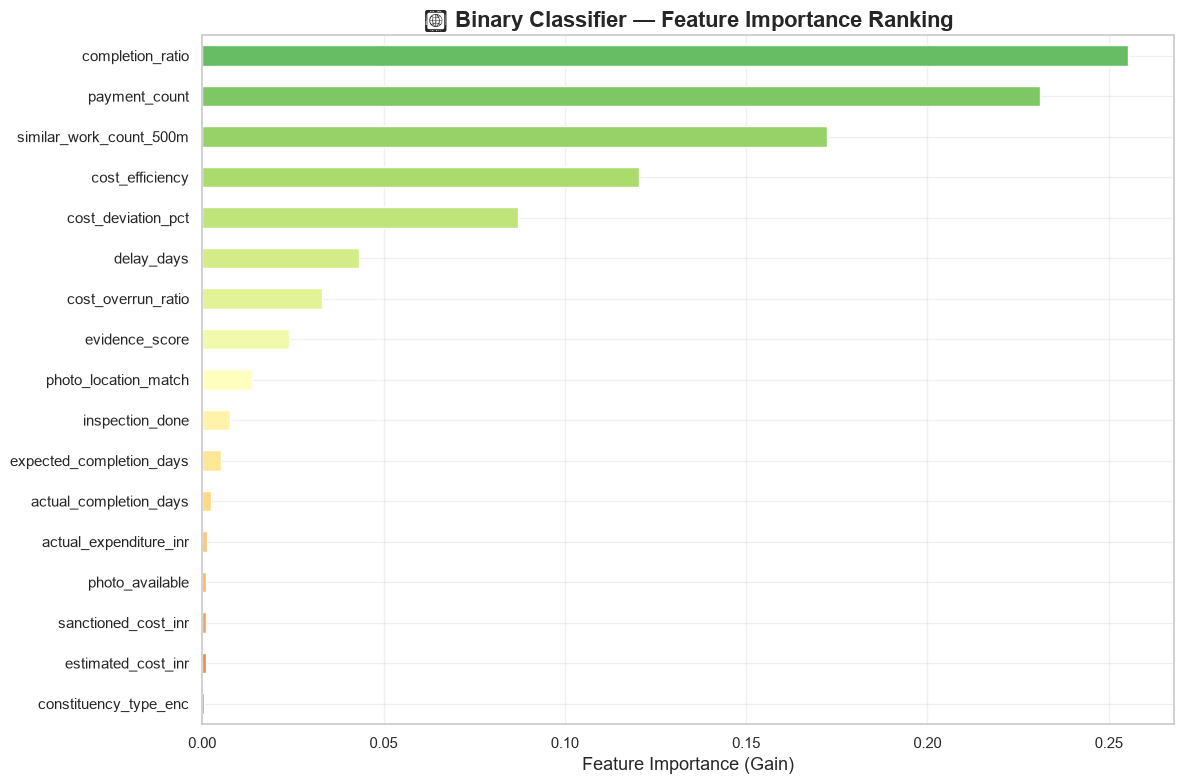

Saved: dataset/plot_binary_feature_importance.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL 1: Feature Importance
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 8))

importances = pd.Series(xgb_binary.feature_importances_, index=X.columns).sort_values(ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importances)))

importances.plot(kind='barh', color=colors, edgecolor='white', linewidth=1, ax=ax)
ax.set_xlabel('Feature Importance (Gain)', fontsize=13)
ax.set_title('🔑 Binary Classifier — Feature Importance Ranking', fontweight='bold', fontsize=16)

plt.tight_layout()
plt.savefig('plots/plot_binary_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_binary_feature_importance.png")

---
## Section 7: Model 2 — XGBoost Multiclass Anomaly Classifier

**Objective**: For anomalous works, classify the specific anomaly archetype:
- `delay_anomaly` | `cost_anomaly` | `duplicate_work` | `ghost_asset` | `vendor_anomaly` | `payment_anomaly`

In [27]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL 2: Multiclass Anomaly Classifier
# ═══════════════════════════════════════════════════════════════════════════

print("Training XGBoost Multiclass Anomaly Classifier...\n")

# Filter to anomalous works only
anom_df = work_df[work_df['is_anomalous'] == 1].copy()

# Encode anomaly types
le_anomaly = LabelEncoder()
anom_df['anomaly_label'] = le_anomaly.fit_transform(anom_df['anomaly_type'])

X_anom = anom_df[FEATURE_COLS + ['constituency_type_enc']].copy()
y_anom = anom_df['anomaly_label'].copy()

# Train-test split
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_anom, y_anom, test_size=0.2, random_state=42, stratify=y_anom
)

print(f"Training set: {X_train_mc.shape[0]:,} anomalous samples")
print(f"Test set:     {X_test_mc.shape[0]:,} anomalous samples")
print(f"Classes:      {len(le_anomaly.classes_)}")
print(f"   {list(le_anomaly.classes_)}")

# Train multiclass XGBoost
xgb_multi = xgb.XGBClassifier(
    n_estimators=250,
    max_depth=7,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.15,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softprob',
    num_class=len(le_anomaly.classes_),
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_multi.fit(X_train_mc, y_train_mc, eval_set=[(X_test_mc, y_test_mc)], verbose=False)

# Predictions
y_pred_mc = xgb_multi.predict(X_test_mc)
y_prob_mc = xgb_multi.predict_proba(X_test_mc)

# Metrics
acc_mc = accuracy_score(y_test_mc, y_pred_mc)
f1_mc = f1_score(y_test_mc, y_pred_mc, average='weighted')

print("\n" + "=" * 60)
print("  MODEL 2: Multiclass Anomaly Classifier — Results")
print("=" * 60)
print(f"  Accuracy:         {acc_mc:.4f}  ({acc_mc*100:.2f}%)")
print(f"  Weighted F1:      {f1_mc:.4f}")
print("=" * 60)

print("\nDetailed Classification Report:")
print(classification_report(y_test_mc, y_pred_mc, target_names=le_anomaly.classes_))

Training XGBoost Multiclass Anomaly Classifier...

Training set: 7,620 anomalous samples
Test set:     1,905 anomalous samples
Classes:      6
   ['cost_anomaly', 'delay_anomaly', 'duplicate_work', 'ghost_asset', 'payment_anomaly', 'vendor_anomaly']

  MODEL 2: Multiclass Anomaly Classifier — Results
  Accuracy:         0.9858  (98.58%)
  Weighted F1:      0.9859

Detailed Classification Report:
                 precision    recall  f1-score   support

   cost_anomaly       0.99      0.98      0.98       471
  delay_anomaly       1.00      1.00      1.00       637
 duplicate_work       1.00      0.99      1.00       336
    ghost_asset       0.99      0.99      0.99       199
payment_anomaly       0.98      0.98      0.98       100
 vendor_anomaly       0.92      0.94      0.93       162

       accuracy                           0.99      1905
      macro avg       0.98      0.98      0.98      1905
   weighted avg       0.99      0.99      0.99      1905



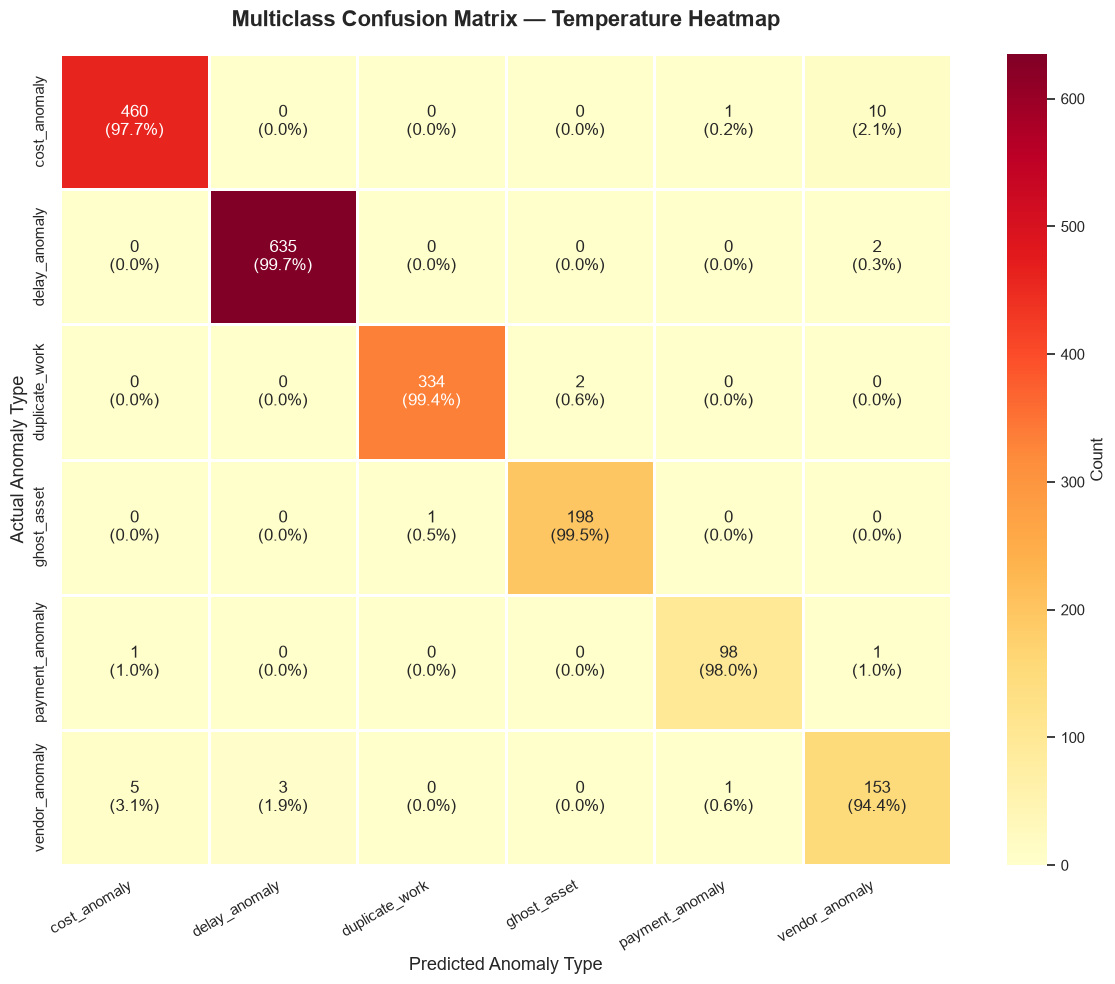

Saved: dataset/plot_multiclass_confusion.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL 2: Confusion Matrix Heatmap
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 10))

cm = confusion_matrix(y_test_mc, y_pred_mc)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create annotation labels with count and percentage
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{cm[i, j]}\n({cm_pct[i, j]:.1f}%)'

sns.heatmap(cm, annot=annot, fmt='', cmap='YlOrRd', linewidths=1,
            xticklabels=le_anomaly.classes_, yticklabels=le_anomaly.classes_,
            cbar_kws={'label': 'Count'}, ax=ax)

ax.set_xlabel('Predicted Anomaly Type', fontsize=13)
ax.set_ylabel('Actual Anomaly Type', fontsize=13)
ax.set_title('Multiclass Confusion Matrix — Temperature Heatmap', fontweight='bold', fontsize=16, pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('plots/plot_multiclass_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_multiclass_confusion.png")

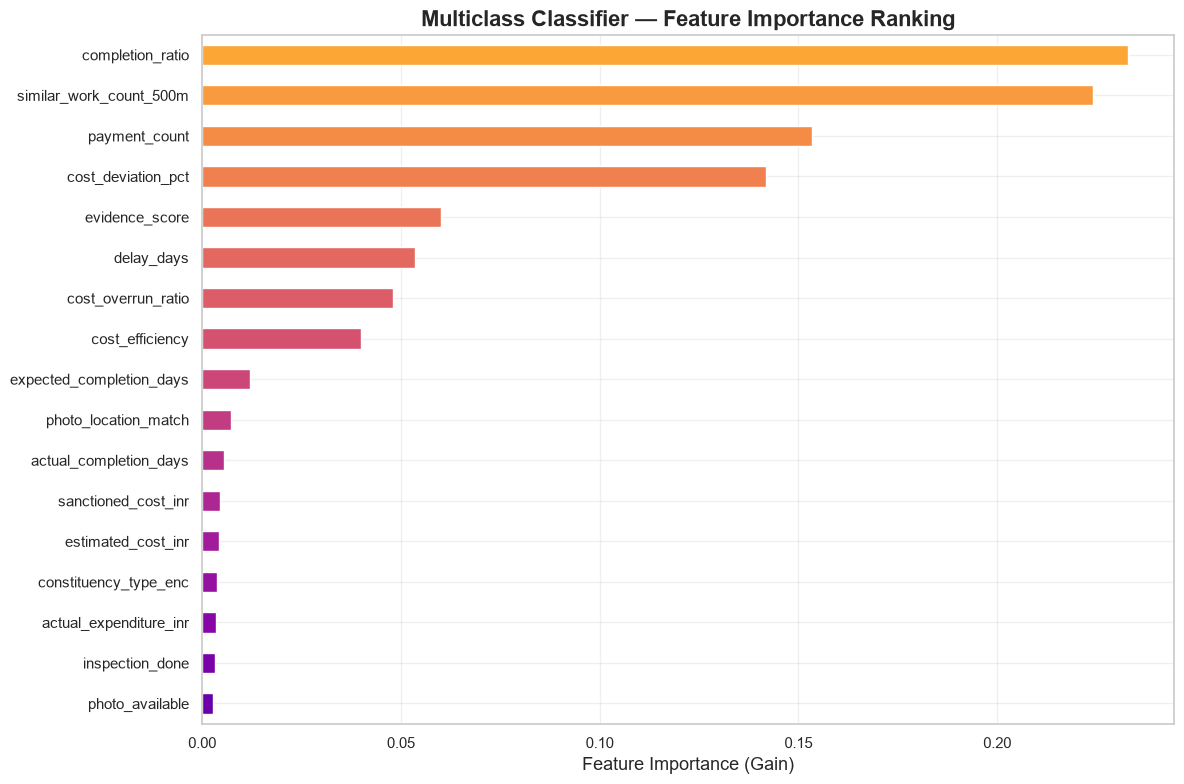

Saved: dataset/plot_multiclass_feature_importance.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL 2: Feature Importance
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 8))

importances_mc = pd.Series(xgb_multi.feature_importances_, index=X_anom.columns).sort_values(ascending=True)
colors_mc = plt.cm.plasma(np.linspace(0.2, 0.8, len(importances_mc)))

importances_mc.plot(kind='barh', color=colors_mc, edgecolor='white', linewidth=1, ax=ax)
ax.set_xlabel('Feature Importance (Gain)', fontsize=13)
ax.set_title('Multiclass Classifier — Feature Importance Ranking', fontweight='bold', fontsize=16)

plt.tight_layout()
plt.savefig('plots/plot_multiclass_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_multiclass_feature_importance.png")

---
## Section 8: Model 3 — Isolation Forest (Unsupervised Outlier Detection)

**Objective**: Detect structural anomalies without labeled ground truth using Isolation Forest.

This model identifies data points that are fundamentally different from the majority — catching novel fraud patterns that supervised models might miss.

In [31]:
# ═══════════════════════════════════════════════════════════════════════════
# 🌲 MODEL 3: Isolation Forest — Unsupervised Outlier Detection
# ═══════════════════════════════════════════════════════════════════════════

print("Training Isolation Forest...\n")

# Features for Isolation Forest
ISO_FEATURES = [
    'estimated_cost_inr', 'sanctioned_cost_inr', 'actual_expenditure_inr',
    'expected_completion_days', 'actual_completion_days',
    'cost_overrun_ratio', 'delay_days', 'payment_count',
    'similar_work_count_500m', 'cost_deviation_pct', 'completion_ratio'
]

X_iso = work_df[ISO_FEATURES].copy()

# Scale features for Isolation Forest
scaler = StandardScaler()
X_iso_scaled = scaler.fit_transform(X_iso)

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=0.10,  # Expected 10% novel outliers
    max_features=1.0,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_iso_scaled)

# Get anomaly scores (more negative = more anomalous)
iso_scores = iso_forest.decision_function(X_iso_scaled)
iso_predictions = iso_forest.predict(X_iso_scaled)  # 1 = normal, -1 = anomaly

# Normalize scores to 0-100 (higher = more anomalous)
iso_scores_norm = ((iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min()) * 100)
iso_scores_norm = 100 - iso_scores_norm  # Invert so higher = more anomalous

work_df['iso_score'] = iso_scores_norm
work_df['iso_outlier'] = (iso_predictions == -1).astype(int)

n_outliers = work_df['iso_outlier'].sum()
n_normal = (work_df['iso_outlier'] == 0).sum()

print("=" * 60)
print("  MODEL 3: Isolation Forest — Results")
print("=" * 60)
print(f"  Normal samples:    {n_normal:,} ({n_normal/len(work_df)*100:.1f}%)")
print(f"  Outlier samples:   {n_outliers:,} ({n_outliers/len(work_df)*100:.1f}%)")
print(f"  Avg ISO score:     {work_df['iso_score'].mean():.2f}")
print(f"  Outlier ISO score: {work_df[work_df['iso_outlier']==1]['iso_score'].mean():.2f}")
print(f"  Normal ISO score:  {work_df[work_df['iso_outlier']==0]['iso_score'].mean():.2f}")
print("=" * 60)

# Agreement with supervised labels
agreement = (work_df['iso_outlier'] == work_df['is_anomalous']).mean()
print(f"\n  Agreement with supervised labels: {agreement*100:.1f}%")

Training Isolation Forest...

  MODEL 3: Isolation Forest — Results
  Normal samples:    13,500 (90.0%)
  Outlier samples:   1,500 (10.0%)
  Avg ISO score:     25.87
  Outlier ISO score: 60.53
  Normal ISO score:  22.02

  Agreement with supervised labels: 46.2%


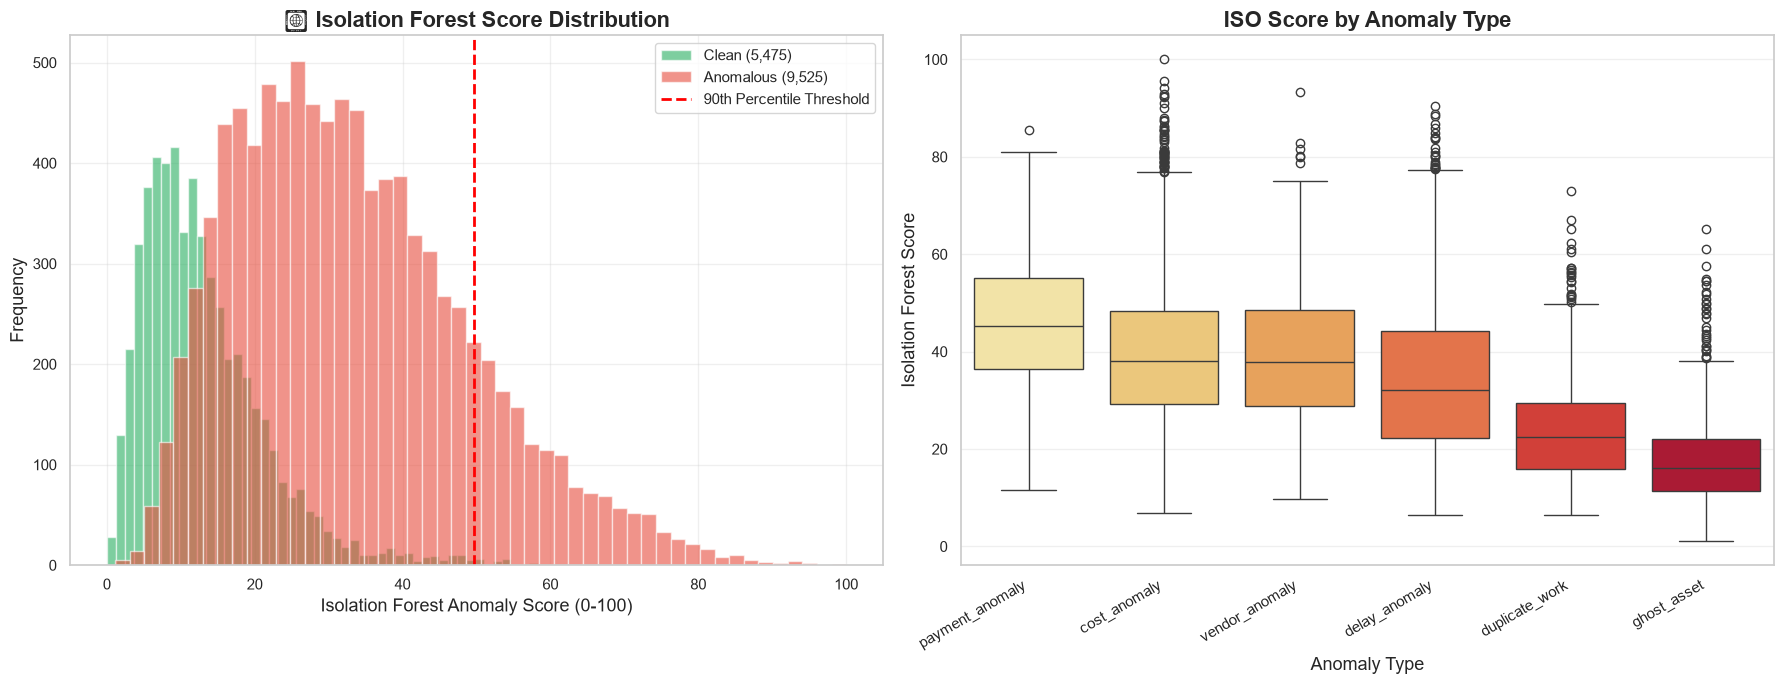

Saved: dataset/plot_isolation_forest.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Isolation Forest — Score Distribution
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Score distribution
for label, color, name in [(0, '#27ae60', 'Clean'), (1, '#e74c3c', 'Anomalous')]:
    data = work_df[work_df['is_anomalous'] == label]['iso_score']
    axes[0].hist(data, bins=50, alpha=0.6, color=color, label=f'{name} ({len(data):,})', edgecolor='white')

axes[0].axvline(x=work_df['iso_score'].quantile(0.90), color='red', linestyle='--', linewidth=2, 
                label='90th Percentile Threshold')
axes[0].set_xlabel('Isolation Forest Anomaly Score (0-100)', fontsize=13)
axes[0].set_ylabel('Frequency', fontsize=13)
axes[0].set_title('🌲 Isolation Forest Score Distribution', fontweight='bold', fontsize=16)
axes[0].legend(fontsize=11)

# Score by anomaly type (box plot)
anom_scores = work_df[work_df['is_anomalous'] == 1].copy()
order = anom_scores.groupby('anomaly_type')['iso_score'].median().sort_values(ascending=False).index
sns.boxplot(data=anom_scores, x='anomaly_type', y='iso_score', order=order,
            palette='YlOrRd', ax=axes[1])
axes[1].set_xlabel('Anomaly Type', fontsize=13)
axes[1].set_ylabel('Isolation Forest Score', fontsize=13)
axes[1].set_title('ISO Score by Anomaly Type', fontweight='bold', fontsize=16)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('plots/plot_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_isolation_forest.png")

---
## Section 9: Risk Fusion Engine — Composite Risk Score

Combines all models into a single **0-100 Risk Score**:

$$R_i = \min\left(100, \; w_1 P_{\text{ML}} + w_2 S_{\text{Iso}} + w_3 R_{\text{Cost}} + w_4 R_{\text{Geo}} + w_5 R_{\text{Evidence}} + w_6 R_{\text{Delay}}\right)$$

In [33]:
# ═══════════════════════════════════════════════════════════════════════════
# RISK FUSION ENGINE — Composite Risk Score (0-100)
# ═══════════════════════════════════════════════════════════════════════════

print("Computing Risk Fusion Scores...\n")

# Weights
W1, W2, W3, W4, W5, W6 = 0.30, 0.15, 0.20, 0.10, 0.15, 0.10

# Component scores
# P_ML: XGBoost binary probability
full_prob = xgb_binary.predict_proba(work_df[FEATURE_COLS + ['constituency_type_enc']])[:, 1] * 100

# S_ISO: Isolation Forest score (already 0-100)
s_iso = work_df['iso_score'].values

# R_COST: Cost overrun ratio
r_cost = np.clip(work_df['cost_overrun_ratio'].values * 100, 0, 100)

# R_GEO: Spatial clustering penalty (25 pts per duplicate)
r_geo = np.clip(work_df['similar_work_count_500m'].values * 25, 0, 100)

# R_EVIDENCE: Evidence quality penalty
r_evidence = np.zeros(len(work_df))
r_evidence += (1 - work_df['photo_location_match'].values) * 50  # GPS mismatch
r_evidence += (1 - work_df['inspection_done'].values) * 30  # No inspection
r_evidence += (1 - work_df['photo_available'].values) * 20  # No photo
r_evidence = np.clip(r_evidence, 0, 100)

# R_DELAY: Statutory delay penalty
r_delay = np.clip((work_df['delay_days'].values - 45).clip(min=0) / 30 * 20, 0, 100)

# Composite Risk Score
risk_score = np.clip(
    W1 * full_prob + W2 * s_iso + W3 * r_cost + W4 * r_geo + W5 * r_evidence + W6 * r_delay,
    0, 100
)

work_df['risk_score'] = np.round(risk_score, 2)

# Assign risk tiers
work_df['risk_tier'] = pd.cut(work_df['risk_score'], 
                               bins=[0, 30, 60, 80, 100], 
                               labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk'],
                               include_lowest=True)

print("=" * 60)
print("  RISK FUSION ENGINE — Summary")
print("=" * 60)
print(f"  Mean Risk Score:   {work_df['risk_score'].mean():.2f}")
print(f"  Median Risk Score: {work_df['risk_score'].median():.2f}")
print(f"  Std Dev:           {work_df['risk_score'].std():.2f}")
print(f"\n  Risk Tier Distribution:")
for tier in ['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']:
    count = (work_df['risk_tier'] == tier).sum()
    pct = count / len(work_df) * 100
    print(f"    {tier:20s}: {count:6,} ({pct:.1f}%)")
print("=" * 60)

Computing Risk Fusion Scores...

  RISK FUSION ENGINE — Summary
  Mean Risk Score:   33.09
  Median Risk Score: 43.74
  Std Dev:           22.71

  Risk Tier Distribution:
    Low Risk            :  5,500 (36.7%)
    Moderate Risk       :  8,685 (57.9%)
    High Risk           :    814 (5.4%)
    Critical Risk       :      1 (0.0%)


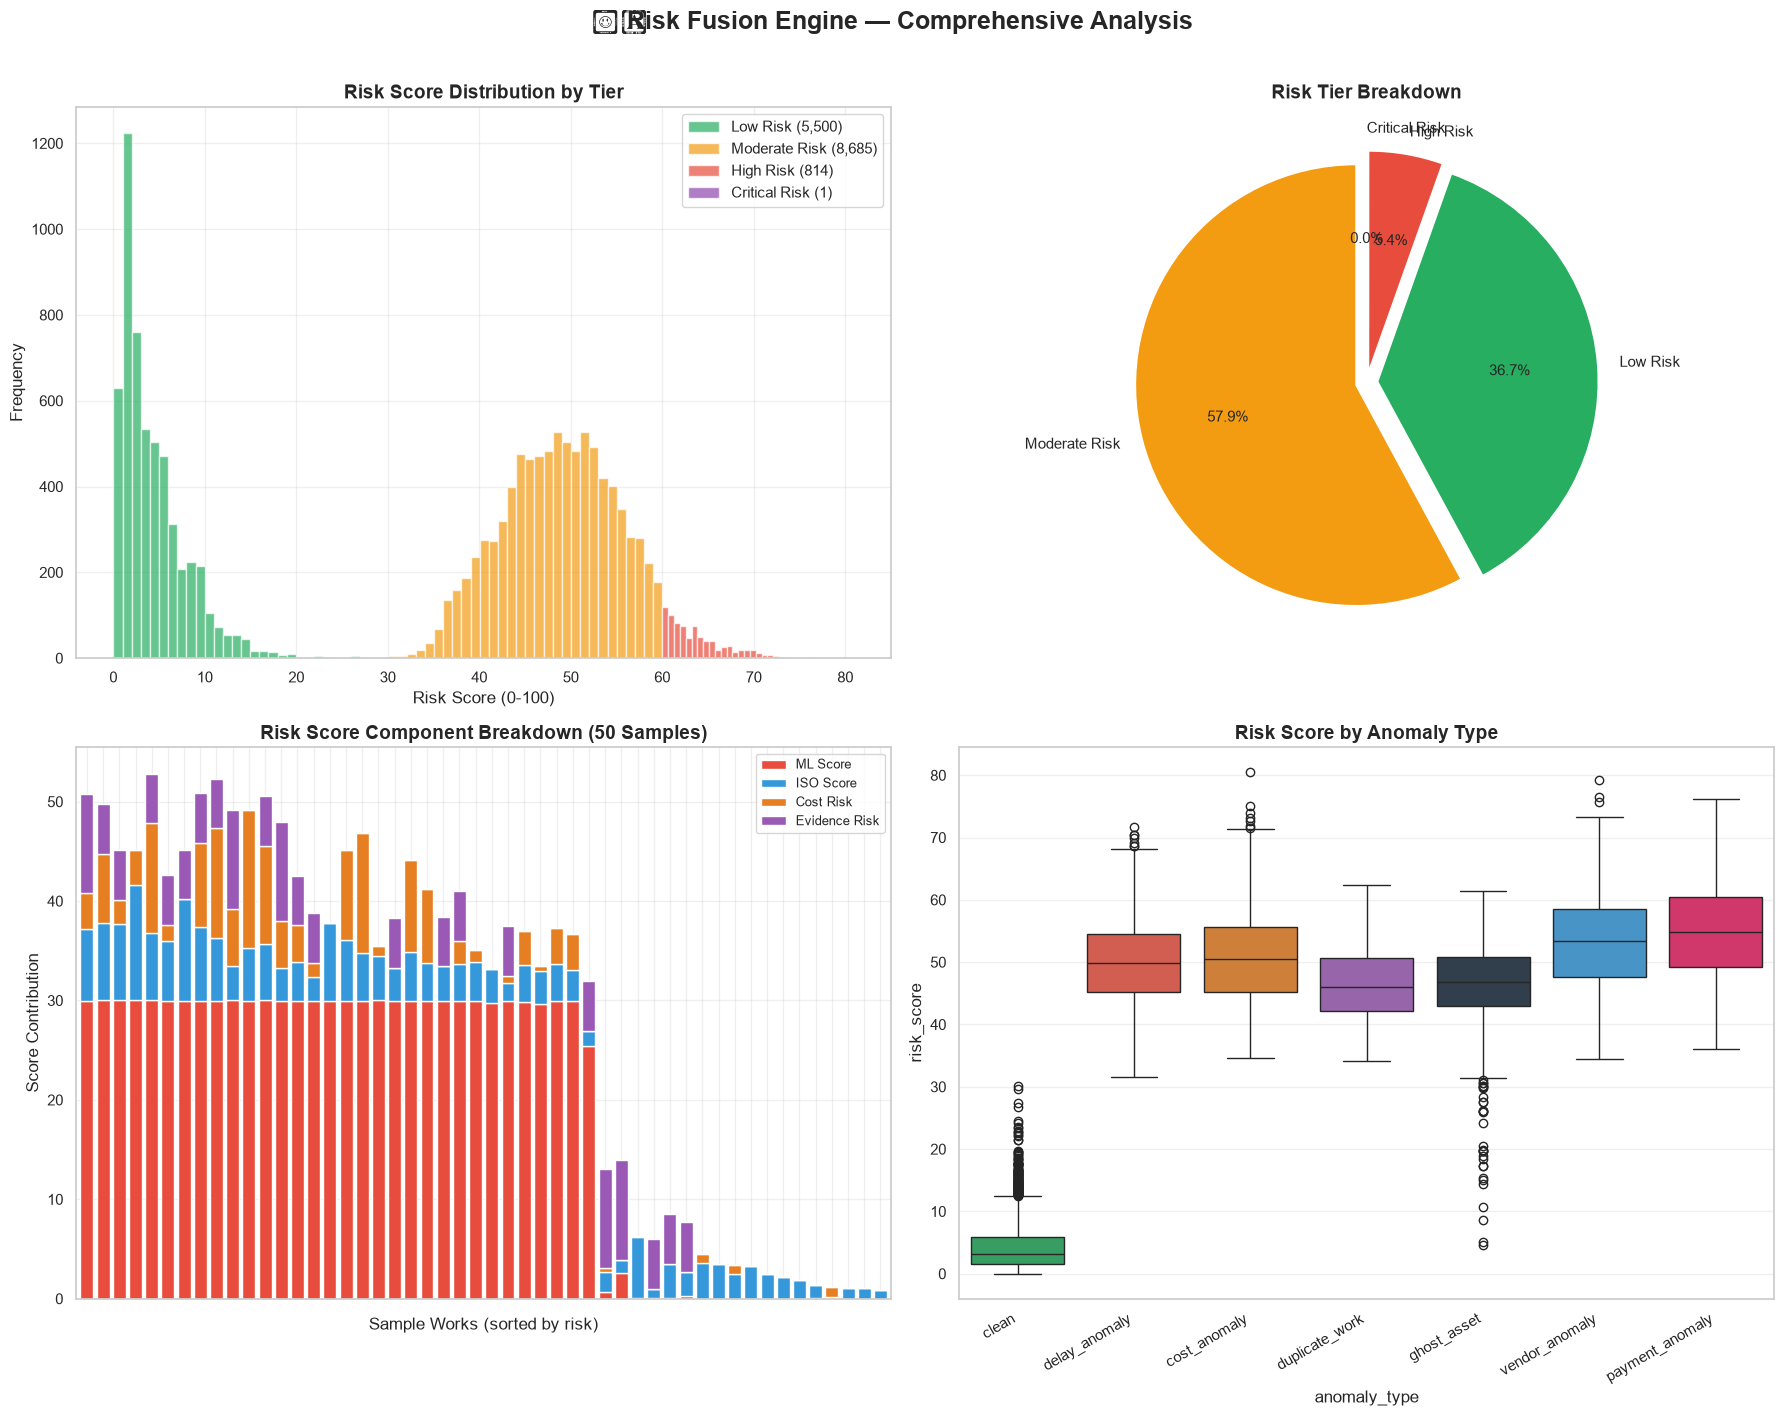

Saved: dataset/plot_risk_fusion.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Risk Score Distribution & Tier Analysis
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Risk Score Distribution
tier_colors_map = {'Low Risk': '#27ae60', 'Moderate Risk': '#f39c12', 
                   'High Risk': '#e74c3c', 'Critical Risk': '#8e44ad'}
for tier in ['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']:
    data = work_df[work_df['risk_tier'] == tier]['risk_score']
    axes[0, 0].hist(data, bins=30, alpha=0.7, color=tier_colors_map[tier], 
                    label=f'{tier} ({len(data):,})', edgecolor='white')
axes[0, 0].set_xlabel('Risk Score (0-100)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Risk Score Distribution by Tier', fontweight='bold', fontsize=14)
axes[0, 0].legend()

# 2. Risk Tier Pie Chart
tier_counts = work_df['risk_tier'].value_counts()
tier_cols = [tier_colors_map[t] for t in tier_counts.index]
axes[0, 1].pie(tier_counts.values, labels=tier_counts.index, colors=tier_cols,
               autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11},
               explode=[0.05]*len(tier_counts))
axes[0, 1].set_title('Risk Tier Breakdown', fontweight='bold', fontsize=14)

# 3. Component Score Contributions (stacked bar for sample)
sample = work_df.sample(50, random_state=42).sort_values('risk_score', ascending=False)
components = pd.DataFrame({
    'ML Score': W1 * xgb_binary.predict_proba(sample[FEATURE_COLS + ['constituency_type_enc']])[:, 1] * 100,
    'ISO Score': W2 * sample['iso_score'].values,
    'Cost Risk': W3 * np.clip(sample['cost_overrun_ratio'].values * 100, 0, 100),
    'Evidence Risk': W5 * (100 - sample['evidence_score'].values * 100),
}, index=range(50))
components.plot(kind='bar', stacked=True, ax=axes[1, 0], width=0.8, 
                color=['#e74c3c', '#3498db', '#e67e22', '#9b59b6'])
axes[1, 0].set_xlabel('Sample Works (sorted by risk)')
axes[1, 0].set_ylabel('Score Contribution')
axes[1, 0].set_title('Risk Score Component Breakdown (50 Samples)', fontweight='bold', fontsize=14)
axes[1, 0].legend(fontsize=9, loc='upper right')
axes[1, 0].set_xticklabels([])

# 4. Risk Score vs Anomaly Type
sns.boxplot(data=work_df, x='anomaly_type', y='risk_score', 
            palette=ANOMALY_COLORS, ax=axes[1, 1],
            order=['clean', 'delay_anomaly', 'cost_anomaly', 'duplicate_work', 
                   'ghost_asset', 'vendor_anomaly', 'payment_anomaly'])
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=30, ha='right')
axes[1, 1].set_title('Risk Score by Anomaly Type', fontweight='bold', fontsize=14)

plt.suptitle('⚖️ Risk Fusion Engine — Comprehensive Analysis', fontweight='bold', fontsize=18, y=1.01)
plt.tight_layout()
plt.savefig('plots/plot_risk_fusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_risk_fusion.png")

---
## Section 10: Final Model Summary & Comparison

In [35]:
# ═══════════════════════════════════════════════════════════════════════════
# FINAL MODEL COMPARISON SUMMARY
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  🏛️ MPLADS-SATHI — MODEL PERFORMANCE SUMMARY")
print("=" * 70)

summary_data = {
    'Model': ['XGBoost Binary', 'XGBoost Multiclass', 'Isolation Forest', 'Risk Fusion Engine'],
    'Type': ['Supervised', 'Supervised', 'Unsupervised', 'Ensemble'],
    'Task': ['Anomaly Detection', '6-Class Classification', 'Outlier Detection', 'Composite Scoring'],
    'Key Metric': [f'ROC-AUC: {roc:.4f}', f'Accuracy: {acc_mc:.4f}', 
                   f'Outliers: {n_outliers:,}', f'Mean Score: {work_df["risk_score"].mean():.1f}'],
}

summary_table = pd.DataFrame(summary_data)
print(summary_table.to_string(index=False))

print("\n" + "=" * 70)
print(" DATASET STATISTICS")
print("=" * 70)
print(f"  Total MPs:           {mp_df.shape[0]}")
print(f"  Total States/UTs:    {work_df['state'].nunique()}")
print(f"  Total Works:         {work_df.shape[0]:,}")
print(f"  Work Categories:     {work_df['work_category'].nunique()}")
print(f"  Features Used:       {len(FEATURE_COLS) + 1}")
print(f"  Anomalous Works:     {work_df['is_anomalous'].sum():,} ({work_df['is_anomalous'].mean()*100:.1f}%)")
print(f"  Clean Works:         {(work_df['is_anomalous']==0).sum():,} ({(work_df['is_anomalous']==0).mean()*100:.1f}%)")
print("=" * 70)
print("\nMPLADS-SATHI Model Pipeline Complete!")

  🏛️ MPLADS-SATHI — MODEL PERFORMANCE SUMMARY
             Model         Type                   Task       Key Metric
    XGBoost Binary   Supervised      Anomaly Detection  ROC-AUC: 0.9998
XGBoost Multiclass   Supervised 6-Class Classification Accuracy: 0.9858
  Isolation Forest Unsupervised      Outlier Detection  Outliers: 1,500
Risk Fusion Engine     Ensemble      Composite Scoring Mean Score: 33.1

 DATASET STATISTICS
  Total MPs:           542
  Total States/UTs:    36
  Total Works:         15,000
  Work Categories:     8
  Features Used:       17
  Anomalous Works:     9,525 (63.5%)
  Clean Works:         5,475 (36.5%)

MPLADS-SATHI Model Pipeline Complete!


In [36]:
# ═══════════════════════════════════════════════════════════════════════════
# TOP 10 RISKIEST MPs (from Fusion Engine)
# ═══════════════════════════════════════════════════════════════════════════

mp_risk = work_df.groupby(['mp_name', 'state']).agg(
    total_works=('work_id', 'count'),
    anomalous_works=('is_anomalous', 'sum'),
    mean_risk_score=('risk_score', 'mean'),
    max_risk_score=('risk_score', 'max'),
    avg_cost_overrun=('cost_overrun_ratio', 'mean'),
    avg_delay=('delay_days', 'mean')
).sort_values('mean_risk_score', ascending=False)

print("\nTOP 10 RISKIEST MPs (by Mean Risk Score):\n")
mp_risk.head(10).round(2)


TOP 10 RISKIEST MPs (by Mean Risk Score):



,,total_works,anomalous_works,mean_risk_score,max_risk_score,avg_cost_overrun,avg_delay
mp_name,state,,,,,,
Rajeev Rai,Uttar Pradesh,5,5,53.73,64.05,0.23,172.60
Shri Rajmohan Unnithan,Kerala,8,8,50.81,64.23,0.14,177.88
Alfred Kanngam S Arthur,Manipur,10,10,50.14,63.75,0.21,132.90
Andrew J. Syngkon,Meghalaya,9,8,48.00,66.80,0.18,112.67
Kali Charan Singh,Jharkhand,15,14,47.90,61.14,0.16,89.53
Krishna Prasad Tenneti,Andhra Pradesh,9,8,46.51,65.79,0.17,111.67
Ambica G Lakshminarayana Valmiki,Andhra Pradesh,17,15,46.17,70.11,0.28,83.41
Dr. Lata Wankhede,Madhya Pradesh,19,16,44.96,67.82,0.18,94.63
V. Somanna,Karnataka,7,6,44.87,58.32,0.17,86.00


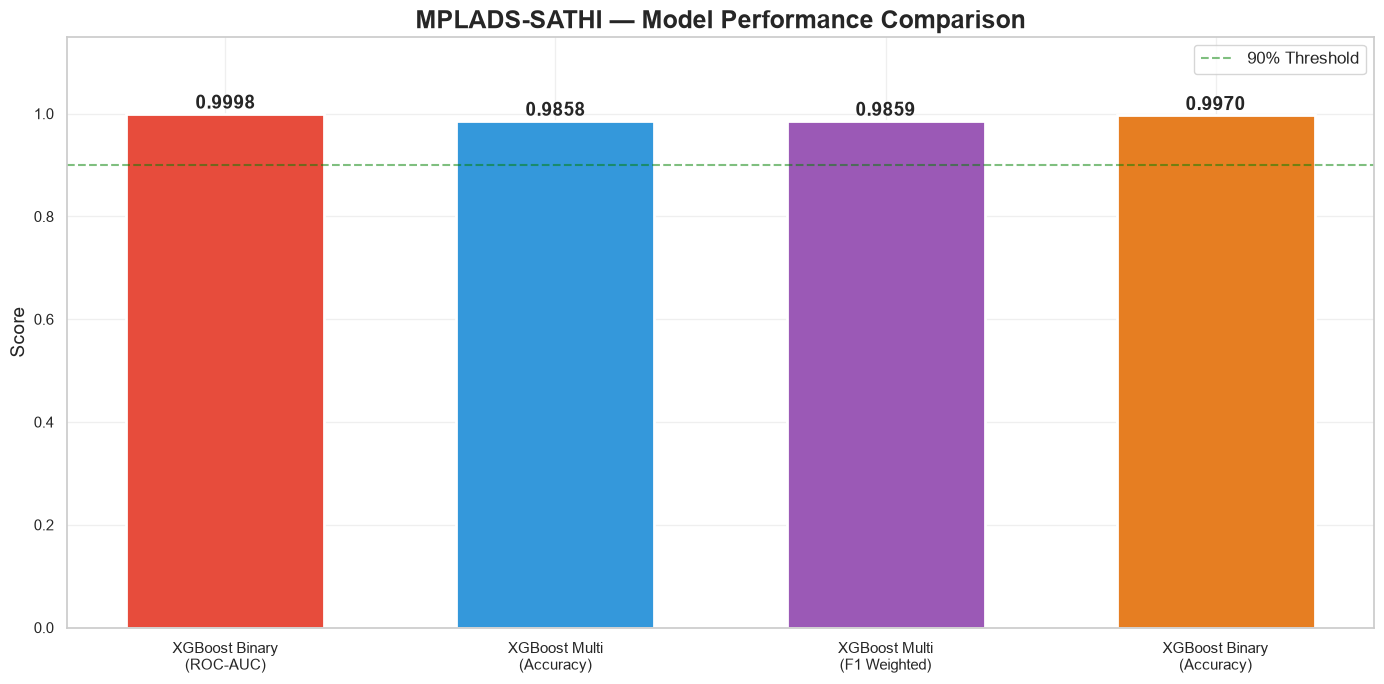

Saved: dataset/plot_model_comparison.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Final Model Comparison Bar Chart
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7))

models = ['XGBoost Binary\n(ROC-AUC)', 'XGBoost Multi\n(Accuracy)', 
          'XGBoost Multi\n(F1 Weighted)', 'XGBoost Binary\n(Accuracy)']
scores = [roc, acc_mc, f1_mc, acc]
colors = ['#e74c3c', '#3498db', '#9b59b6', '#e67e22']

bars = ax.bar(models, scores, color=colors, edgecolor='white', linewidth=2, width=0.6)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{score:.4f}', ha='center', fontweight='bold', fontsize=14)

ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=14)
ax.set_title('MPLADS-SATHI — Model Performance Comparison', fontweight='bold', fontsize=18)
ax.axhline(y=0.90, color='green', linestyle='--', alpha=0.5, label='90% Threshold')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('plots/plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/plot_model_comparison.png")

---
## Pipeline Complete!

All 3 models trained and evaluated. The Risk Fusion Engine combines supervised and unsupervised signals into a single actionable score.

**Generated Artifacts:**
- `dataset/mplads_mp_table.csv` — 542 MPs across 36 states
- `dataset/mplads_work_table.csv` — 15,000 works with features
- `dataset/mplads_mp_risk_leaderboard.csv` — Ranked risk leaderboard
- Multiple visualization PNGs in `plots/`

**Team CodeByPrakash | SIH 2026** 